
## Preliminary EDA / feasibility analysis of **OpenFake `core` / `test`** (supplementary OOD dataset)


| Section | Content |
|---|---|
| 1 | Project & dataset introduction |
| 2 | Reproducible, stratified **streaming** sample (no full download) |
| 3 | Raw metadata table (`raw_df`) |
| 4 | Cleaning / validation (`cleaned_df`) |
| 5 | Preliminary EDA plots |
| 6 | Visual inspection (contact sheets) |
| 7 | Metadata-shortcut diagnostic (interpretable tree, *not* a detector) |
| 8 | Generator / source analysis |
| 9 | Lightweight forensic (FFT) profiling |
| 10 | Dataset integrity / leakage checks |
| 11 | Comparison with Defactify |
| 12 | Final findings (generated from notebook output) |
| 13 | Export |

## SECTION 1 — Project & dataset introduction

**What is OpenFake?**  
`ComplexDataLab/OpenFake` is a Hugging Face dataset of real and AI-generated images designed for synthetic-image / deepfake detection research. The fields used in this notebook are `image`, `label`, `model`, `prompt`, `type` and `release_date`.

**Why `core / test`?**  
The `core/test` split is intended as an **out-of-distribution (OOD) / generalisation** split, containing generator models not seen in training and real images from different sources. This makes it particularly relevant to Mad-Eye Moody Lens for examining **source diversity and potential generalisation challenges** before model development.

**Why is this analysis relevant to the project?**  
Rather than treating OpenFake as only a real-vs-AI classification dataset, this analysis examines its **class distribution, generator/source diversity, image properties, data quality, metadata shortcuts and frequency-domain characteristics**. These checks help determine whether the dataset provides useful variation for future detector development and evaluation.

**Scope and dataset scale**  
The `core/test` split contains **91,398 records**. A bounded sample of **3,000 images** was analysed instead of processing the complete split:
- **1,500 real images**
- **1,500 AI-generated images**
- **3,000 total sampled records**
- **2,998 records retained after duplicate removal**

All EDA and forensic observations in this notebook are therefore based on this **3,000-image analysed sample**, not the complete 91,398-record split.

**Scope and caveats**
* The analysis is **preliminary** and focuses on dataset characterization and feasibility rather than training or evaluating a detector.
* The OpenFake dataset documentation reports known prompt–image mismatches for some generators; therefore, `prompt` is not used as a label-validation criterion.
* Findings and numerical results reported below are derived from the actual analysed sample.

## SECTION 2 — Reproducible streaming sample

**Sampling design (deterministic, documented, fixed seed):**

Because the OpenFake `core/test` split contains **91,398 records**, processing the complete split was unnecessary for this preliminary dataset-feasibility study. A **bounded sample of 3,000 records** was therefore selected using the reproducible streaming procedure implemented below.

The selected sample was designed to provide sufficient coverage for analysing:
- real vs. AI-generated class distribution;
- generator and real-source diversity;
- image dimensions and aspect ratios;
- data-quality and integrity issues;
- metadata-based shortcuts;
- representative visual characteristics;
- exploratory FFT patterns.





In [1]:
# ============================== SECTION 2.0 — setup & configuration ==============================
import importlib, subprocess, sys, os, io, gc, math, time, random, shutil, hashlib, warnings
from collections import Counter


def ensure(pip_name, import_name=None):
    # Import a package; pip-install it only if it is missing.
    import_name = import_name or pip_name
    try:
        importlib.import_module(import_name)
    except ImportError:
        print(f"Installing missing package: {pip_name}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])
        importlib.invalidate_caches()
        importlib.import_module(import_name)


for _pip, _imp in [("datasets", "datasets"), ("pillow", "PIL"), ("pandas", "pandas"),
                   ("numpy", "numpy"), ("matplotlib", "matplotlib"), ("scikit-learn", "sklearn")]:
    ensure(_pip, _imp)

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from PIL import Image, ImageFile
from IPython.display import display, Markdown
from datasets import load_dataset
from datasets import Image as HFImage

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")
warnings.simplefilter("ignore", Image.DecompressionBombWarning)
Image.MAX_IMAGE_PIXELS = 250_000_000          # allow large images, still bounded
ImageFile.LOAD_TRUNCATED_IMAGES = False       # truncated files must be flagged as unreadable

# ---------------- dataset ----------------
DATASET_ID = "ComplexDataLab/OpenFake"
CONFIG = "core"
SPLIT = "test"

# ---------------- sampling (all tunable, all documented) ----------------
SEED = 42
TARGET_REAL = 1500
TARGET_FAKE = 1500
TARGET_TOTAL = TARGET_REAL + TARGET_FAKE
REAL_GROUP_CAP = 1500        # max reservoir size per real source (disk bound)
FAKE_GROUP_CAP = 300         # max reservoir size per fake generator (disk bound)
MAX_SCAN_ROWS = 14000        # hard row budget for the streamed scan (NOT the full dataset)
SCAN_TIME_LIMIT_MIN = 25     # hard time budget for the scan
SHUFFLE_BUFFER = 300         # streaming shuffle buffer (rows)

# ---------------- cleaning ----------------
MIN_SIDE_SOFT_FLAG = 64      # images with a shorter side than this are only *flagged*

# ---------------- paths (temporary storage under /content) ----------------
WORK_DIR = "/content/openfake_work"
POOL_DIR = os.path.join(WORK_DIR, "pool")
OUT_DIR = "/content/openfake_outputs"
RAW_CSV = os.path.join(OUT_DIR, "openfake_raw.csv")
CLEAN_CSV = os.path.join(OUT_DIR, "openfake_cleaned.csv")
REMOVED_CSV = os.path.join(OUT_DIR, "openfake_removed_rows.csv")
SUMMARY_TXT = os.path.join(OUT_DIR, "openfake_eda_summary.txt")

random.seed(SEED)
np.random.seed(SEED)

shutil.rmtree(POOL_DIR, ignore_errors=True)   # start every run from a clean pool
os.makedirs(POOL_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

REAL_COLOR, FAKE_COLOR = "#1f77b4", "#d62728"
LABEL_COLORS = {"real": REAL_COLOR, "fake": FAKE_COLOR}
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
                     "axes.spines.right": False})
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 200)

print("Python", sys.version.split()[0], "| pandas", pd.__version__, "| numpy", np.__version__)
print(f"Dataset: {DATASET_ID} | config={CONFIG!r} | split={SPLIT!r} | seed={SEED}")
print(f"Targets: real={TARGET_REAL}, fake={TARGET_FAKE} | scan budget={MAX_SCAN_ROWS} rows / {SCAN_TIME_LIMIT_MIN} min")

Python 3.13.15 | pandas 2.2.3 | numpy 2.1.3
Dataset: ComplexDataLab/OpenFake | config='core' | split='test' | seed=42
Targets: real=1500, fake=1500 | scan budget=14000 rows / 25 min


In [2]:
# ============================== SECTION 2.1 — helper functions ==============================
def is_missing(v):
    if v is None:
        return True
    if isinstance(v, float) and math.isnan(v):
        return True
    if isinstance(v, str) and v.strip().lower() in ("", "none", "nan", "null", "n/a", "<na>"):
        return True
    try:
        if v is pd.NA or v is pd.NaT:
            return True
    except Exception:
        pass
    return False


def clean_text(v, default=None):
    return default if is_missing(v) else str(v).strip()


def norm_label(v, label_feature=None):
    # Returns "real", "fake" or None (invalid / ambiguous). Integer codes are only accepted if the
    # dataset schema (ClassLabel) tells us the names; we never guess which integer means which class.
    if is_missing(v):
        return None
    if isinstance(v, (int, np.integer)) and not isinstance(v, bool):
        if label_feature is not None and hasattr(label_feature, "int2str"):
            try:
                v = label_feature.int2str(int(v))
            except Exception:
                return None
        else:
            return None
    if isinstance(v, bool):
        return None
    s = str(v).strip().lower()
    if s in ("real", "authentic", "genuine", "human"):
        return "real"
    if s in ("fake", "synthetic", "ai", "ai-generated", "ai_generated", "generated"):
        return "fake"
    return None


def to_iso(v):
    if is_missing(v):
        return None
    if hasattr(v, "isoformat"):
        try:
            return v.isoformat()
        except Exception:
            pass
    return str(v).strip()


def get_image_bytes(img):
    # Returns (bytes | None, path_inside_dataset | None, re-encoded flag).
    if isinstance(img, dict):
        b, p = img.get("bytes"), img.get("path")
        if b is None and p and os.path.exists(str(p)):
            with open(p, "rb") as fh:
                b = fh.read()
        return (bytes(b) if b is not None else None), p, False
    if isinstance(img, (bytes, bytearray)):
        return bytes(img), None, False
    if hasattr(img, "save"):                       # decoded PIL image (fallback path only)
        buf = io.BytesIO()
        try:
            img.save(buf, format="PNG")
        except Exception:
            img.convert("RGB").save(buf, format="PNG")
        return buf.getvalue(), None, True
    return None, None, False


def waterfill(avail, target):
    # Spread `target` items as evenly as possible over groups with limited availability.
    # avail: {group_key: n_available}. Deterministic (sorted keys). Returns {group_key: n_selected}.
    alloc = {k: 0 for k in avail}
    active = sorted(k for k, n in avail.items() if n > 0)
    remaining = int(target)
    while remaining > 0 and active:
        share = remaining // len(active)
        if share == 0:                               # fewer items than groups: one each, deterministic order
            for k in active[:remaining]:
                alloc[k] += 1
            remaining = 0
            break
        for k in active:
            give = min(share, avail[k] - alloc[k])
            alloc[k] += give
            remaining -= give
        active = [k for k in active if alloc[k] < avail[k]]
    return alloc


def md5_of_file(path, chunk=1 << 20):
    h = hashlib.md5()
    with open(path, "rb") as fh:
        for block in iter(lambda: fh.read(chunk), b""):
            h.update(block)
    return h.hexdigest()


def inspect_image(path):
    # Open + fully decode one image safely. Never raises.
    out = {"width": np.nan, "height": np.nan, "channels": np.nan, "mode": None, "format": None,
           "readable": False, "error": None}
    try:
        with Image.open(path) as im:
            fmt, (w, h), mode, nb = im.format, im.size, im.mode, len(im.getbands())
            im.load()
        out.update(width=int(w), height=int(h), channels=int(nb), mode=mode, format=fmt, readable=True)
    except Exception as e:
        out["error"] = f"{type(e).__name__}: {str(e)[:120]}"
    return out


def parse_dates(series):
    try:
        out = pd.to_datetime(series, errors="coerce", utc=True, format="mixed")
    except (TypeError, ValueError):
        out = pd.to_datetime(series, errors="coerce", utc=True)
    return out.dt.tz_localize(None)


def fmt(x, digits=3, pct=False):
    if x is None:
        return "n/a"
    try:
        if isinstance(x, float) and (math.isnan(x) or math.isinf(x)):
            return "n/a"
    except Exception:
        pass
    if pct:
        return f"{float(x):.1f}%"
    if isinstance(x, (int, np.integer)):
        return f"{int(x):,}"
    if isinstance(x, (float, np.floating)):
        return f"{float(x):.{digits}f}"
    return str(x)


print("Helper functions defined.")

Helper functions defined.


In [3]:
# ============================== SECTION 2.2 — open the stream & scan with seeded reservoirs ==============================
class SchemaError(Exception):
    pass


REQUIRED_FIELDS = ["image", "label"]                       # without these the analysis is impossible
EXPECTED_FIELDS = ["model", "type", "release_date", "prompt"]   # handled gracefully if absent


def open_stream():
    ds = load_dataset(DATASET_ID, CONFIG, split=SPLIT, streaming=True)   # streaming: nothing is materialised
    feats = getattr(ds, "features", None)
    decode_off = False
    try:
        ds = ds.cast_column("image", HFImage(decode=False))             # keep the ORIGINAL encoded bytes
        decode_off = True
    except Exception as e:
        print(f"[warn] could not disable image decoding ({type(e).__name__}); will re-encode decoded images as PNG "
              "(file format / size columns would then be unreliable - flagged in `bytes_reencoded`).")
    ds = ds.shuffle(seed=SEED, buffer_size=SHUFFLE_BUFFER)             # seeded shard/buffer shuffle
    return ds, feats, decode_off


print(f"Opening stream: load_dataset({DATASET_ID!r}, {CONFIG!r}, split={SPLIT!r}, streaming=True) ...")
try:
    ds_stream, ds_features, decode_off = open_stream()
except Exception as e:
    raise RuntimeError(f"Could not open the OpenFake stream ({type(e).__name__}: {e}). Check the Colab internet "
                       "connection and that the dataset id / config / split names are still valid.") from e

label_feature = None
try:
    if ds_features is not None and "label" in ds_features:
        label_feature = ds_features["label"]
except Exception:
    label_feature = None

rng_res = random.Random(SEED)          # single seeded RNG for all reservoir decisions
pool = {}                              # (label, model) -> {"seen": int, "items": [record, ...]}
scan_stats = Counter()
schema_checked = False
missing_optional_fields = []
rows_scanned = 0
scan_status = "interrupted"
t_scan0 = time.time()

try:
    for row in ds_stream:
        if not schema_checked:
            missing_req = [c for c in REQUIRED_FIELDS if c not in row]
            if missing_req:
                raise SchemaError(f"Required field(s) {missing_req} not found in the OpenFake rows. "
                                  f"Fields present: {sorted(row.keys())}. The dataset schema has changed; "
                                  "update REQUIRED_FIELDS / field names before running this notebook.")
            missing_optional_fields = [c for c in EXPECTED_FIELDS if c not in row]
            print("Fields present in a streamed row:", sorted(row.keys()))
            if missing_optional_fields:
                print(f"[warn] optional field(s) missing: {missing_optional_fields} -> they will be treated as missing values.")
            schema_checked = True

        if rows_scanned >= MAX_SCAN_ROWS:
            scan_status = "row budget reached"
            break
        if time.time() - t_scan0 > SCAN_TIME_LIMIT_MIN * 60:
            scan_status = "time limit reached"
            break

        idx = rows_scanned
        rows_scanned += 1

        label = norm_label(row.get("label"), label_feature)
        if label is None:
            scan_stats["invalid_label_rows"] += 1
            continue

        model_raw = row.get("model") if "model" in row else None
        model_missing = is_missing(model_raw)
        model = "unknown_model" if model_missing else str(model_raw).strip()

        data, orig_path, reencoded = get_image_bytes(row["image"])
        if data is None:
            scan_stats["no_image_bytes_rows"] += 1
            continue

        scan_stats[f"scanned_{label}"] += 1
        key = (label, model)
        grp = pool.setdefault(key, {"seen": 0, "items": []})
        grp["seen"] += 1
        cap = REAL_GROUP_CAP if label == "real" else FAKE_GROUP_CAP

        slot = None
        if len(grp["items"]) < cap:
            slot = len(grp["items"])
        else:
            j = rng_res.randrange(grp["seen"])       # classic reservoir sampling (Algorithm R)
            if j < cap:
                slot = j

        if slot is not None:
            path = os.path.join(POOL_DIR, f"{idx:07d}.img")
            with open(path, "wb") as fh:
                fh.write(data)
            prompt_val = row.get("prompt") if "prompt" in row else None
            rec = {"scan_index": idx, "path": path, "label": label, "model": model,
                   "model_missing": bool(model_missing),
                   "type": clean_text(row.get("type")) if "type" in row else None,
                   "release_date": to_iso(row.get("release_date")) if "release_date" in row else None,
                   "prompt_available": (not is_missing(prompt_val)),
                   "prompt_length_chars": (len(str(prompt_val)) if not is_missing(prompt_val) else 0),
                   "dataset_path": (str(orig_path) if orig_path else None),
                   "bytes_reencoded": bool(reencoded)}
            if slot < len(grp["items"]):             # replace an evicted reservoir member
                old = grp["items"][slot]
                try:
                    os.remove(old["path"])
                except OSError:
                    pass
                grp["items"][slot] = rec
            else:
                grp["items"].append(rec)

        if rows_scanned % 1000 == 0:
            print(f"  scanned {rows_scanned:>6,} rows | {time.time() - t_scan0:6.0f}s | groups so far: {len(pool)}")
    else:
        scan_status = "stream exhausted (the whole split was smaller than the scan budget)"
except SchemaError:
    raise
except Exception as e:
    if rows_scanned == 0:
        raise RuntimeError(f"Streaming failed before any row was read ({type(e).__name__}: {e}).") from e
    scan_status = f"interrupted by {type(e).__name__} after {rows_scanned} rows (partial scan is used)"
    print(f"[warn] {scan_status}")

try:
    del ds_stream
except NameError:
    pass
gc.collect()

print("\n--- scan finished ---")
print("status                :", scan_status)
print("rows scanned          :", rows_scanned)
print("elapsed (s)           :", round(time.time() - t_scan0, 1))
print("valid real rows seen  :", scan_stats["scanned_real"])
print("valid fake rows seen  :", scan_stats["scanned_fake"])
print("invalid-label rows    :", scan_stats["invalid_label_rows"])
print("rows w/o image bytes  :", scan_stats["no_image_bytes_rows"])
print("groups found          :", len(pool), "| image bytes decoding disabled:", decode_off)
if not pool:
    raise RuntimeError("No valid (label, model) groups were collected. Check the label values / schema printed above.")
if not any(k[0] == "real" for k in pool) or not any(k[0] == "fake" for k in pool):
    raise RuntimeError("The scanned portion contains only one class (real or fake); a real-vs-fake analysis is not possible. "
                       "Increase MAX_SCAN_ROWS or inspect the label field.")

Opening stream: load_dataset('ComplexDataLab/OpenFake', 'core', split='test', streaming=True) ...


README.md:   0%|          | 0.00/15.6k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/608 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/608 [00:00<?, ?it/s]

Fields present in a streamed row: ['image', 'image_sha256', 'label', 'model', 'prompt', 'prompt_kind', 'prompt_model', 'prompt_revision', 'prompt_version', 'release_date', 'row_id', 'type']
  scanned  1,000 rows |    177s | groups so far: 22
  scanned  2,000 rows |    324s | groups so far: 22
  scanned  3,000 rows |    474s | groups so far: 22
  scanned  4,000 rows |    687s | groups so far: 22
  scanned  5,000 rows |    902s | groups so far: 22
  scanned  6,000 rows |   1120s | groups so far: 22

--- scan finished ---
status                : time limit reached
rows scanned          : 6879
elapsed (s)           : 1513.0
valid real rows seen  : 3478
valid fake rows seen  : 3401
invalid-label rows    : 0
rows w/o image bytes  : 0
groups found          : 22 | image bytes decoding disabled: True


In [4]:
# ============================== SECTION 2.3 — automatic allocation & deterministic final selection ==============================
real_avail = {k: len(v["items"]) for k, v in pool.items() if k[0] == "real"}
fake_avail = {k: len(v["items"]) for k, v in pool.items() if k[0] == "fake"}
alloc = {}
alloc.update(waterfill(real_avail, TARGET_REAL))
alloc.update(waterfill(fake_avail, TARGET_FAKE))

rng_sel = random.Random(SEED + 1)
selected_records, dropped_files = [], 0
for key in sorted(pool):
    items = sorted(pool[key]["items"], key=lambda r: r["scan_index"])
    k = alloc.get(key, 0)
    chosen = rng_sel.sample(items, k) if k > 0 else []
    chosen_idx = {r["scan_index"] for r in chosen}
    for r in items:
        if r["scan_index"] not in chosen_idx:
            try:
                os.remove(r["path"])
                dropped_files += 1
            except OSError:
                pass
    selected_records.extend(chosen)

selected_records = sorted(selected_records, key=lambda r: r["scan_index"])
for r in selected_records:
    r["sample_id"] = f"OF{r['scan_index']:06d}"
if not selected_records:
    raise RuntimeError("Selection produced zero images.")

alloc_rows = []
for key in sorted(pool):
    alloc_rows.append({"label": key[0], "source_group(model)": key[1], "seen_in_scan": pool[key]["seen"],
                       "reservoir_size": len(pool[key]["items"]), "selected": alloc.get(key, 0)})
allocation_df = pd.DataFrame(alloc_rows)
sel_df = pd.DataFrame(selected_records)

n_sel_real = int((sel_df["label"] == "real").sum())
n_sel_fake = int((sel_df["label"] == "fake").sum())
shortfall_real = TARGET_REAL - n_sel_real
shortfall_fake = TARGET_FAKE - n_sel_fake

print("=" * 80)
print("SAMPLING METHOD (documented)")
print("=" * 80)
print(f"- Stream: {DATASET_ID} / {CONFIG} / {SPLIT} (streaming=True; dataset never materialised)")
print(f"- Seeded shuffle (seed={SEED}, buffer={SHUFFLE_BUFFER}); scan of at most {MAX_SCAN_ROWS} rows; status: {scan_status}")
print(f"- Per-group seeded reservoir sampling (caps: real={REAL_GROUP_CAP}, fake={FAKE_GROUP_CAP}); final draw seeded with {SEED + 1}")
print(f"- Targets: real~{TARGET_REAL}, fake~{TARGET_FAKE}, allocated by water-filling across OBSERVED groups")
print("=" * 80)
print(f"\nTOTAL SAMPLED IMAGES : {len(sel_df)}  (target {TARGET_TOTAL})")
print(f"Real / Fake          : {n_sel_real} / {n_sel_fake}")
if shortfall_real > 0 or shortfall_fake > 0:
    print(f"[note] shortfall vs target -> real: {max(shortfall_real, 0)}, fake: {max(shortfall_fake, 0)} "
          "(groups had too few images in the scanned portion; counts below are the feasible ones).")

print("\nSamples selected from EACH group (seen in scan / reservoir / selected):")
print(allocation_df.to_string(index=False))

print("\nFake image counts by generator (`model`):")
print(sel_df[sel_df["label"] == "fake"]["model"].value_counts().to_string())
print("\nReal image counts by source (`model` value of real rows):")
print(sel_df[sel_df["label"] == "real"]["model"].value_counts().to_string())
print("\nType counts (by label):")
print(pd.crosstab(sel_df["type"].fillna("(missing)"), sel_df["label"]).to_string())

_rd = parse_dates(sel_df["release_date"])
print("\nRelease-date summary of the selected sample:")
for _lab in ["real", "fake"]:
    _s = _rd[sel_df["label"] == _lab]
    if _s.notna().any():
        print(f"  {_lab}: non-missing={int(_s.notna().sum())}/{len(_s)} | min={_s.min().date()} | median={_s.median().date()} | max={_s.max().date()}")
    else:
        print(f"  {_lab}: no parsable release_date values ({len(_s)} rows)")
print(f"\nTemporary files kept: {len(sel_df)} | unselected reservoir files deleted: {dropped_files}")

SAMPLING METHOD (documented)
- Stream: ComplexDataLab/OpenFake / core / test (streaming=True; dataset never materialised)
- Seeded shuffle (seed=42, buffer=300); scan of at most 14000 rows; status: time limit reached
- Per-group seeded reservoir sampling (caps: real=1500, fake=300); final draw seeded with 43
- Targets: real~1500, fake~1500, allocated by water-filling across OBSERVED groups

TOTAL SAMPLED IMAGES : 3000  (target 3000)
Real / Fake          : 1500 / 1500

Samples selected from EACH group (seen in scan / reservoir / selected):
label source_group(model)  seen_in_scan  reservoir_size  selected
 fake      aurora-20-1-25            23              23        23
 fake         ernie-image            32              32        32
 fake   ernie-image-turbo            60              60        60
 fake     flux.2-klein-9b           622             300       168
 fake      frames-23-1-25            22              22        22
 fake       gpt-image-1.5           427             300    

## SECTION 3 — Raw metadata table (`raw_df`)

`raw_df` describes the selected sample **before any cleaning**. Every selected image is opened once (full decode) to read its properties; images that fail to decode are kept and flagged (`readable = False`).
`source_group` is the value of the dataset's `model` field (generator name for fake rows; real-image source for real rows). `group_key` is `label::model`.
`prompt` text is **not stored**; only `prompt_available` / `prompt_length_chars` (descriptive). `file_path` is a temporary `/content/...` path and is dropped from the CSV export.

In [5]:
# ============================== SECTION 3 — build raw_df ==============================
RAW_COLUMNS = ["sample_id", "label", "model", "type", "release_date", "prompt_available", "prompt_length_chars",
               "width", "height", "channels", "mode", "format", "file_size_bytes", "aspect_ratio", "readable",
               "source_group", "group_key", "model_missing", "md5", "scan_index", "dataset_path",
               "bytes_reencoded", "decode_error", "file_path"]

raw_rows = []
_t0 = time.time()
for i, rec in enumerate(selected_records):
    info = inspect_image(rec["path"])
    w, h = info["width"], info["height"]
    ar = (w / h) if (info["readable"] and h and h > 0) else np.nan
    raw_rows.append({
        "sample_id": rec["sample_id"], "label": rec["label"], "model": rec["model"], "type": rec["type"],
        "release_date": rec["release_date"], "prompt_available": rec["prompt_available"],
        "prompt_length_chars": rec["prompt_length_chars"], "width": w, "height": h, "channels": info["channels"],
        "mode": info["mode"], "format": info["format"], "file_size_bytes": os.path.getsize(rec["path"]),
        "aspect_ratio": ar, "readable": bool(info["readable"]), "source_group": rec["model"],
        "group_key": f"{rec['label']}::{rec['model']}", "model_missing": rec["model_missing"],
        "md5": md5_of_file(rec["path"]), "scan_index": rec["scan_index"], "dataset_path": rec["dataset_path"],
        "bytes_reencoded": rec["bytes_reencoded"], "decode_error": info["error"], "file_path": rec["path"]})
    if (i + 1) % 500 == 0:
        print(f"  inspected {i + 1}/{len(selected_records)} images ({time.time() - _t0:.0f}s)")

raw_df = pd.DataFrame(raw_rows, columns=RAW_COLUMNS)
raw_df = raw_df.sort_values("sample_id").reset_index(drop=True)

print(f"\nraw_df shape: {raw_df.shape}")
display(raw_df.drop(columns=["file_path"]).head(8))
print("\nDtypes:")
print(raw_df.dtypes.to_string())

raw_df.drop(columns=["file_path"]).to_csv(RAW_CSV, index=False)
print(f"\nSaved: {RAW_CSV}")

  inspected 500/3000 images (15s)
  inspected 1000/3000 images (31s)
  inspected 1500/3000 images (47s)
  inspected 2000/3000 images (63s)
  inspected 2500/3000 images (77s)
  inspected 3000/3000 images (92s)

raw_df shape: (3000, 24)


,sample_id,label,model,type,release_date,prompt_available,prompt_length_chars,width,height,channels,mode,format,file_size_bytes,aspect_ratio,readable,source_group,group_key,model_missing,md5,scan_index,dataset_path,bytes_reencoded,decode_error
0,OF000000,real,docci,real,None,True,533,359,480,3,RGB,JPEG,11014,0.747917,True,docci,real::docci,False,53dccf181a4e0dc11e7a45710a76b6f7,0,train_00032.jpg,False,None
1,OF000003,fake,veo-3,video,2025-10,True,168,1280,720,3,RGB,JPEG,163294,1.777778,True,veo-3,fake::veo-3,False,2e352e8bb19c1d210f7623d6502d44c4,3,0295837.jpg,False,None
2,OF000004,real,docci,real,None,True,727,1535,2048,3,RGB,JPEG,497080,0.749512,True,docci,real::docci,False,97880b994ceab3ce2c01ac9dfb00f040,4,test_01142.jpg,False,None
3,OF000005,fake,veo-3,video,2026-02,True,214,1080,1920,3,RGB,JPEG,482330,0.562500,True,veo-3,fake::veo-3,False,42767f831d12d5eda23315019a742df6,5,0209684.jpg,False,None
4,OF000008,fake,ernie-image-turbo,image,2026-04,True,541,1024,1024,3,RGB,JPEG,191524,1.000000,True,ernie-image-turbo,fake::ernie-image-turbo,False,adc9876df81c11a44affdb4713b6b6d0,8,0075770.jpg,False,None
5,OF000010,real,docci,real,None,True,661,1535,2048,3,RGB,JPEG,340783,0.749512,True,docci,real::docci,False,a4f2a331654eb0d65d055cc0b559f97f,10,test_01000.jpg,False,None
6,OF000015,fake,gpt-image-2,image,2026-04,True,175,1024,1024,3,RGB,JPEG,231684,1.000000,True,gpt-image-2,fake::gpt-image-2,False,966e1f561e9a9188d2eebc22a29b54e1,15,0015605.jpg,False,None
7,OF000019,real,docci,real,None,True,645,2048,1536,3,RGB,JPEG,548805,1.333333,True,docci,real::docci,False,7398280787ce242519493e133e814c48,19,train_06691.jpg,False,None



Dtypes:
sample_id               object
label                   object
model                   object
type                    object
release_date            object
prompt_available          bool
prompt_length_chars      int64
width                    int64
height                   int64
channels                 int64
mode                    object
format                  object
file_size_bytes          int64
aspect_ratio           float64
readable                  bool
source_group            object
group_key               object
model_missing             bool
md5                     object
scan_index               int64
dataset_path            object
bytes_reencoded           bool
decode_error            object
file_path               object

Saved: /content/openfake_outputs/openfake_raw.csv


## SECTION 4 — Cleaning / validation (`cleaned_df`)

Principle: **suspicious data is flagged, not silently deleted.** Every check produces a boolean `flag_*` column. Only rows that cannot be used *reliably* for a real-vs-fake image analysis are excluded, and they are written to a separate `removed_df` (exported as `openfake_removed_rows.csv`) with an explicit `exclusion_reason`.

| Check | Treatment |
|---|---|
| Image cannot be decoded | flagged + excluded |
| Invalid dimensions (non-positive / missing) | flagged + excluded |
| Invalid label (not real/fake) | flagged + excluded (rows with invalid labels cannot enter the sampling stage, so the count of such rows is taken from the scan statistics) |
| Missing `model` | **kept**, filled with `unknown_model`, flagged |
| Exact duplicate (same MD5) within one label | first occurrence kept, extra copies flagged + excluded |
| Same MD5 under *both* labels | label is ambiguous -> **all** members flagged + excluded |
| Very small image (short side < `MIN_SIDE_SOFT_FLAG`), missing `type`, missing / unparsable `release_date` | flagged only (kept) |
| Metadata normalisation | labels lower-cased, text trimmed, `type` lower-cased, `format` upper-cased, `release_date` parsed to `release_date_parsed` |

In [6]:
# ============================== SECTION 4 — cleaning ==============================
df = raw_df.copy().sort_values("sample_id").reset_index(drop=True)
n_raw = len(df)

# ---- basic metadata normalisation (raw_df itself is left untouched) ----
df["label"] = df["label"].map(lambda v: str(v).strip().lower())
df["model"] = df["model"].map(lambda v: "unknown_model" if is_missing(v) else str(v).strip())
df["source_group"] = df["model"]
df["type"] = df["type"].map(lambda v: None if is_missing(v) else str(v).strip().lower())
df["format"] = df["format"].map(lambda v: v.strip().upper() if isinstance(v, str) else v)
df["release_date_parsed"] = parse_dates(df["release_date"])
df["readable"] = df["readable"].astype(bool)

# ---- flags ----
num_ok = df["width"].notna() & df["height"].notna() & (df["width"] > 0) & (df["height"] > 0)
df["flag_unreadable"] = ~df["readable"]
df["flag_invalid_dims"] = df["readable"] & ~num_ok
df["flag_invalid_label"] = ~df["label"].isin(["real", "fake"])
df["flag_missing_model"] = df["model_missing"].astype(bool)
df["flag_tiny_image"] = df["readable"] & num_ok & (np.minimum(df["width"], df["height"]) < MIN_SIDE_SOFT_FLAG)
df["flag_missing_type"] = df["type"].isna()
df["flag_missing_release_date"] = df["release_date"].map(is_missing)
df["flag_bad_release_date"] = (~df["flag_missing_release_date"]) & df["release_date_parsed"].isna()

grp_size = df.groupby("md5")["sample_id"].transform("size")
grp_labels = df.groupby("md5")["label"].transform("nunique")
df["flag_in_duplicate_group"] = grp_size > 1
df["flag_label_conflict_duplicate"] = grp_labels > 1                         # same bytes under real AND fake
df["flag_exact_duplicate_extra"] = df.duplicated("md5", keep="first") & ~df["flag_label_conflict_duplicate"]

EXCLUSION_FLAGS = {"unreadable": "flag_unreadable", "invalid_dimensions": "flag_invalid_dims",
                   "invalid_label": "flag_invalid_label", "label_conflicting_duplicate": "flag_label_conflict_duplicate",
                   "exact_duplicate_extra_copy": "flag_exact_duplicate_extra"}


def exclusion_reason(row):
    return ";".join(name for name, col in EXCLUSION_FLAGS.items() if bool(row[col]))


df["exclusion_reason"] = df.apply(exclusion_reason, axis=1)
df["keep_for_analysis"] = df["exclusion_reason"] == ""

cleaned_df = df[df["keep_for_analysis"]].copy().reset_index(drop=True)
removed_df = df[~df["keep_for_analysis"]].copy().reset_index(drop=True)
n_clean = len(cleaned_df)

# ---- counts for the report ----
n_unreadable = int(df["flag_unreadable"].sum())
n_invalid_dims = int(df["flag_invalid_dims"].sum())
n_invalid_label_rows_sampled = int(df["flag_invalid_label"].sum())
n_invalid_label_scan = int(scan_stats["invalid_label_rows"])
n_invalid_meta = n_invalid_dims + n_invalid_label_rows_sampled
n_dup_extra = int(df["flag_exact_duplicate_extra"].sum())
n_dup_in_groups = int(df["flag_in_duplicate_group"].sum())
n_label_conflict = int(df["flag_label_conflict_duplicate"].sum())
n_missing_model = int(df["flag_missing_model"].sum())
n_tiny = int(df["flag_tiny_image"].sum())
n_missing_type = int(df["flag_missing_type"].sum())
n_missing_date = int(df["flag_missing_release_date"].sum())
n_bad_date = int(df["flag_bad_release_date"].sum())
n_reencoded = int(df["bytes_reencoded"].astype(bool).sum())
retention_pct = 100.0 * n_clean / n_raw if n_raw else float("nan")

print("=" * 70)
print("CLEANING REPORT")
print("=" * 70)
print(f"Rows before cleaning                          : {n_raw}")
print(f"Rows after cleaning (cleaned_df)              : {n_clean}")
print(f"Rows excluded (removed_df)                    : {len(removed_df)}")
print(f"Unreadable images                             : {n_unreadable}")
print(f"Invalid dimensions                            : {n_invalid_dims}")
print(f"Invalid labels among sampled rows             : {n_invalid_label_rows_sampled}")
print(f"Invalid-label rows met during the scan (never sampled): {n_invalid_label_scan}")
print(f"Invalid metadata count (dims + labels, sampled) : {n_invalid_meta}")
print(f"Exact duplicates (extra copies, same label)   : {n_dup_extra}")
print(f"Rows inside any MD5-duplicate group           : {n_dup_in_groups}")
print(f"Rows in label-conflicting duplicate groups    : {n_label_conflict}")
print(f"Missing `model` (kept as 'unknown_model')     : {n_missing_model}")
print(f"Soft flags (kept): tiny={n_tiny} | missing type={n_missing_type} | missing release_date={n_missing_date} | unparsable release_date={n_bad_date}")
print(f"Images whose bytes had to be re-encoded       : {n_reencoded}")
print(f"RETENTION                                     : {retention_pct:.2f}%")

if len(removed_df):
    print("\nExclusion reasons:")
    print(removed_df["exclusion_reason"].value_counts().to_string())

print("\nMissing-value summary (raw_df):")
_mv = pd.DataFrame({"n_missing": raw_df.drop(columns=["file_path"]).isna().sum(),
                    "pct_missing": (100 * raw_df.drop(columns=["file_path"]).isna().mean()).round(2)})
print(_mv[_mv["n_missing"] > 0].to_string() if (_mv["n_missing"] > 0).any() else "  no NaN/None values in raw_df")
print("\nMissing-value summary (cleaned_df, key columns):")
_keycols = ["label", "model", "type", "release_date", "release_date_parsed", "width", "height", "channels", "format",
            "file_size_bytes", "aspect_ratio"]
print(pd.DataFrame({"n_missing": cleaned_df[_keycols].isna().sum(),
                    "pct_missing": (100 * cleaned_df[_keycols].isna().mean()).round(2)}).to_string())

print("\nLabel counts after cleaning:", cleaned_df["label"].value_counts().to_dict())
if cleaned_df["label"].nunique() < 2:
    raise RuntimeError("After cleaning only one class remains; the remaining analysis would be meaningless.")

cleaned_df.drop(columns=["file_path"]).to_csv(CLEAN_CSV, index=False)
removed_df.drop(columns=["file_path"]).to_csv(REMOVED_CSV, index=False)
print(f"\nSaved: {CLEAN_CSV}\nSaved: {REMOVED_CSV}")

CLEANING REPORT
Rows before cleaning                          : 3000
Rows after cleaning (cleaned_df)              : 2998
Rows excluded (removed_df)                    : 2
Unreadable images                             : 0
Invalid dimensions                            : 0
Invalid labels among sampled rows             : 0
Invalid-label rows met during the scan (never sampled): 0
Invalid metadata count (dims + labels, sampled) : 0
Exact duplicates (extra copies, same label)   : 2
Rows inside any MD5-duplicate group           : 4
Rows in label-conflicting duplicate groups    : 0
Missing `model` (kept as 'unknown_model')     : 0
Soft flags (kept): tiny=0 | missing type=0 | missing release_date=1500 | unparsable release_date=131
Images whose bytes had to be re-encoded       : 0
RETENTION                                     : 99.93%

Exclusion reasons:
exclusion_reason
exact_duplicate_extra_copy    2

Missing-value summary (raw_df):
              n_missing  pct_missing
release_date       1500

## SECTION 5 — Preliminary EDA

All plots use `cleaned_df`. Blue = real, red = fake. Width / height / aspect-ratio histograms show the 0.5–99.5 percentile range so that a few extreme values do not hide the bulk of the distribution; histograms are normalised per class (density) so the two classes can be compared even if the counts differ.

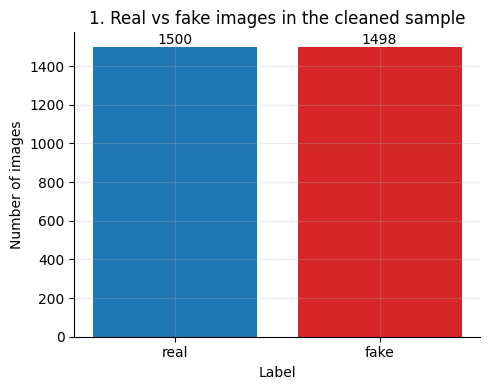

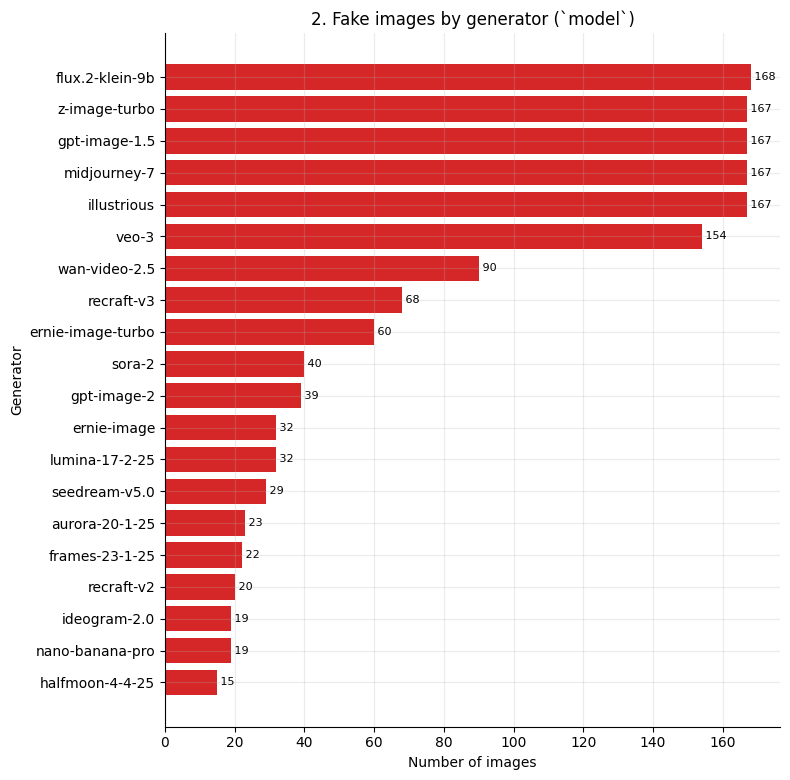

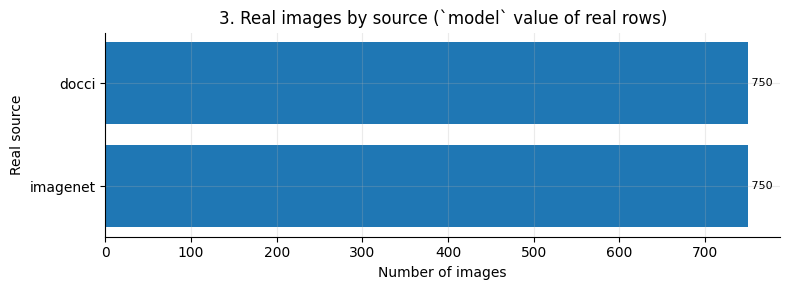

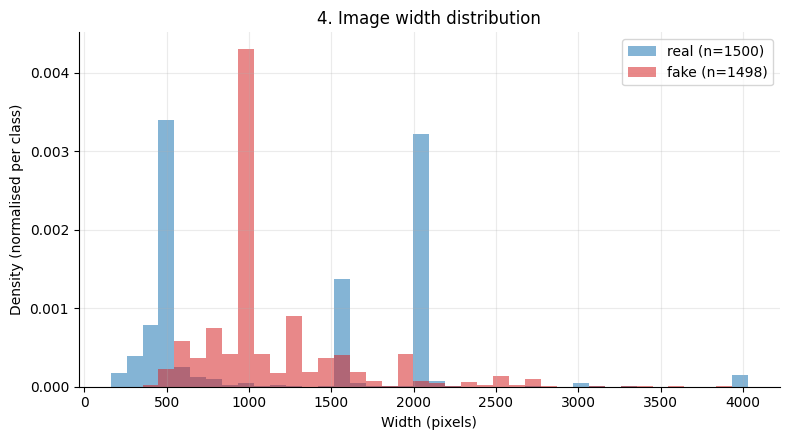

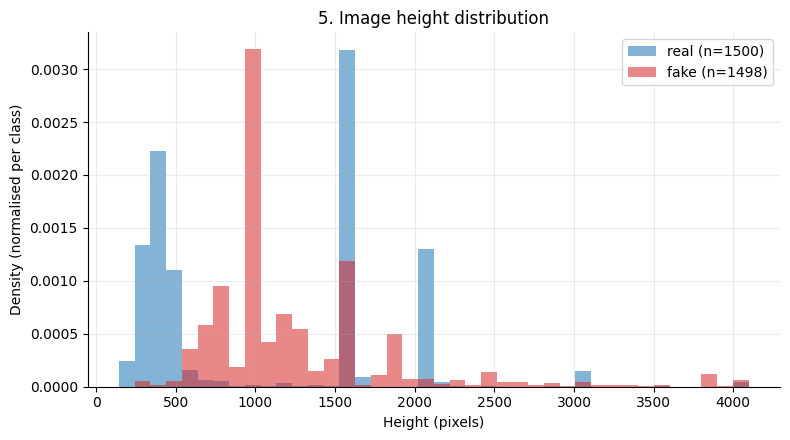

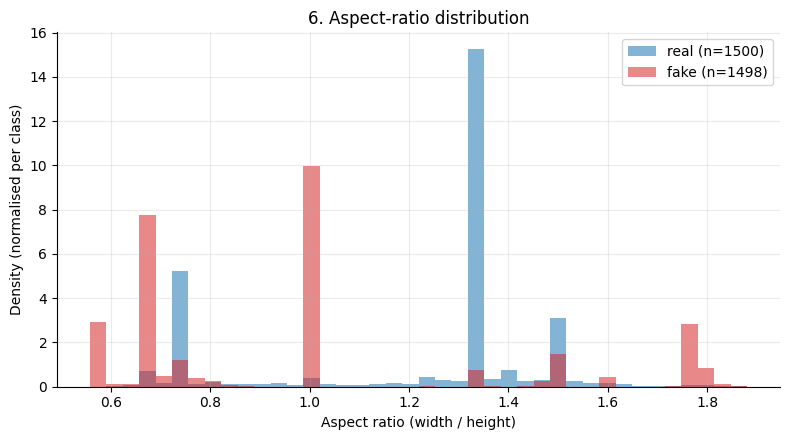

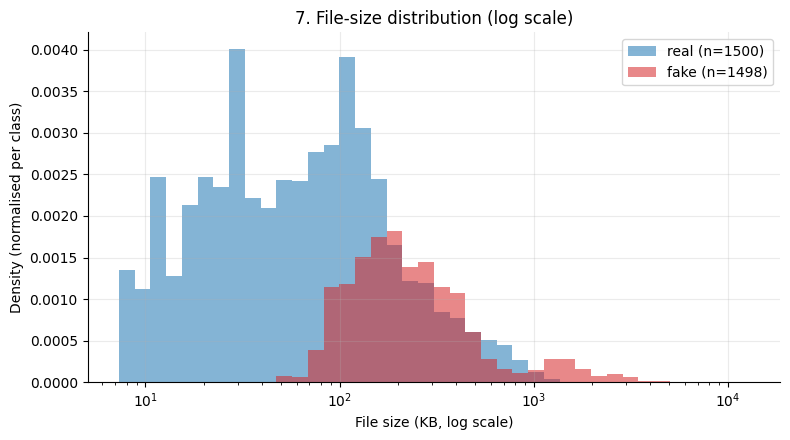

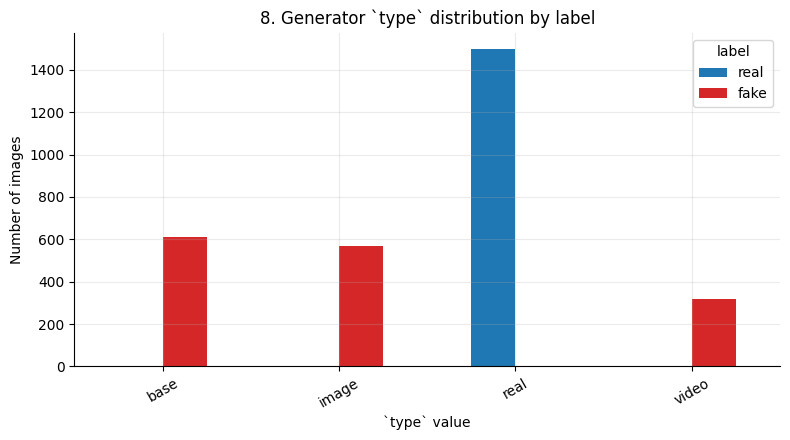

label  fake  real
type             
base    610     0
image   570     0
real      0  1500
video   318     0


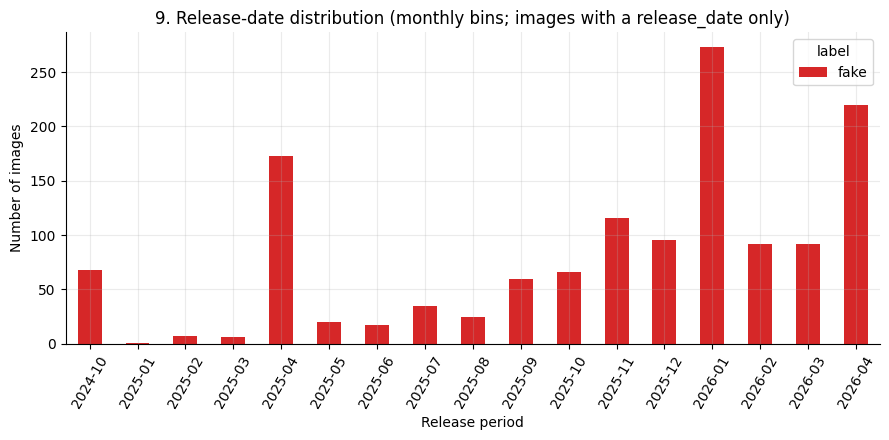

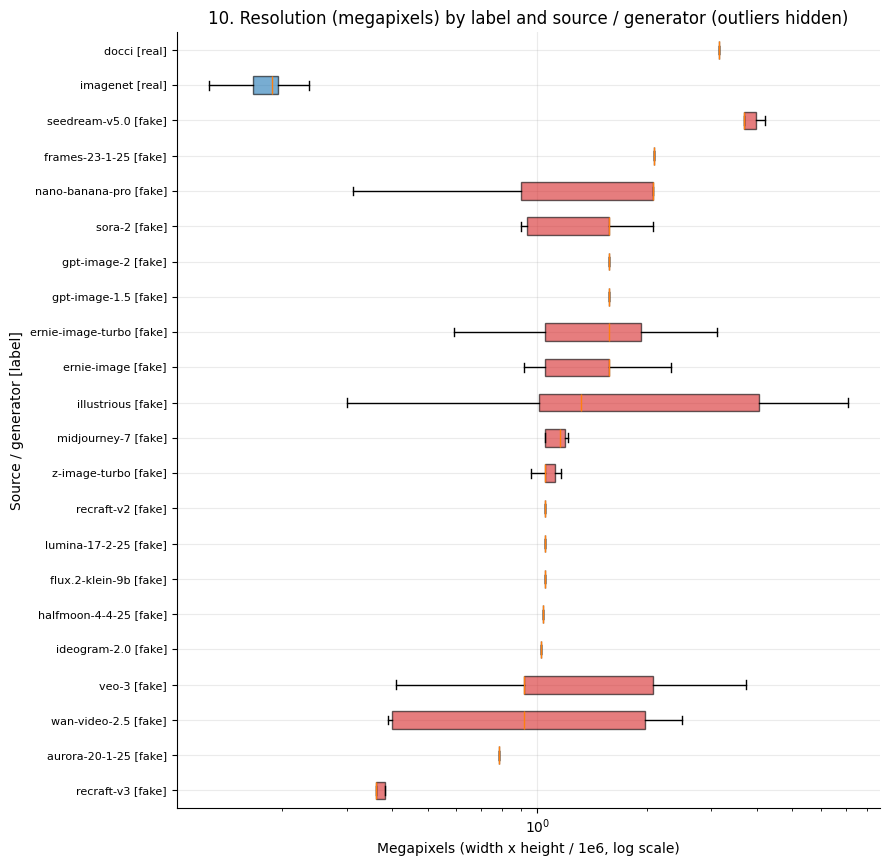


Per-label descriptive statistics:
label                     fake      real
width        median   1024.000   726.500
             min       416.000    96.000
             max      4392.000  4288.000
height       median   1024.000   600.000
             min       300.000    64.000
             max      6144.000  4032.000
aspect_ratio median      1.000     1.333
             min         0.428     0.615
             max         3.184     2.994
megapixels   median      1.049     0.424
             min         0.180     0.006
             max        25.166    12.212
file_size_kb median    454.384   191.647
             min        47.679     1.716
             max     19655.190  2918.336

Format counts by label:
label   fake  real
format            
JPEG     926  1500
PNG      556     0
WEBP      16     0

Channel counts by label:
label     fake  real
channels            
1            0     2
3         1477  1498
4           21     0


In [7]:
# ============================== SECTION 5 — EDA plots ==============================
eda_df = cleaned_df.copy()
eda_df["megapixels"] = eda_df["width"] * eda_df["height"] / 1e6
eda_df["file_size_kb"] = eda_df["file_size_bytes"] / 1024.0
fake_eda = eda_df[eda_df["label"] == "fake"]
real_eda = eda_df[eda_df["label"] == "real"]


def bar_counts(counts, title, xlabel, ylabel, color, horizontal=False, figsize=(8, 4.5)):
    if len(counts) == 0:
        print(f"[skip] {title}: no data")
        return
    fig, ax = plt.subplots(figsize=figsize)
    if horizontal:
        ax.barh(counts.index.astype(str)[::-1], counts.values[::-1], color=color)
        for y_, v_ in enumerate(counts.values[::-1]):
            ax.text(v_, y_, f" {v_}", va="center", fontsize=8)
    else:
        bars = ax.bar(counts.index.astype(str), counts.values, color=color)
        for b_, v_ in zip(bars, counts.values):
            ax.text(b_.get_x() + b_.get_width() / 2, v_, f"{v_}", ha="center", va="bottom", fontsize=9)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    plt.tight_layout()
    plt.show()


# 1. real vs fake
_lc = eda_df["label"].value_counts().reindex(["real", "fake"]).fillna(0).astype(int)
fig, ax = plt.subplots(figsize=(5, 4))
_b = ax.bar(_lc.index, _lc.values, color=[REAL_COLOR, FAKE_COLOR])
for b_, v_ in zip(_b, _lc.values):
    ax.text(b_.get_x() + b_.get_width() / 2, v_, str(v_), ha="center", va="bottom")
ax.set_title("1. Real vs fake images in the cleaned sample")
ax.set_xlabel("Label")
ax.set_ylabel("Number of images")
plt.tight_layout()
plt.show()

# 2. fake by generator
_h = max(3.5, 0.32 * fake_eda["source_group"].nunique() + 1.5)
bar_counts(fake_eda["source_group"].value_counts(), "2. Fake images by generator (`model`)", "Number of images",
           "Generator", FAKE_COLOR, horizontal=True, figsize=(8, _h))

# 3. real by source
_h = max(3.0, 0.4 * real_eda["source_group"].nunique() + 1.5)
bar_counts(real_eda["source_group"].value_counts(), "3. Real images by source (`model` value of real rows)",
           "Number of images", "Real source", REAL_COLOR, horizontal=True, figsize=(8, _h))


def hist_by_label(df_, col, title, xlabel, log_x=False, bins=40, pct_clip=(0.5, 99.5)):
    vals_all = df_[col].astype(float)
    vals_all = vals_all[np.isfinite(vals_all)]
    if log_x:
        vals_all = vals_all[vals_all > 0]
    if len(vals_all) == 0:
        print(f"[skip] {title}: no data")
        return
    lo, hi = np.percentile(vals_all, pct_clip)
    if not hi > lo:
        lo, hi = float(vals_all.min()) - 0.5, float(vals_all.max()) + 0.5
        if log_x and lo <= 0:
            lo = float(vals_all.min()) * 0.9
    edges = np.logspace(np.log10(lo), np.log10(hi), bins + 1) if log_x else np.linspace(lo, hi, bins + 1)
    fig, ax = plt.subplots(figsize=(8, 4.5))
    for lab in ["real", "fake"]:
        v = df_.loc[df_["label"] == lab, col].astype(float)
        v = v[np.isfinite(v)]
        if len(v):
            ax.hist(v, bins=edges, alpha=0.55, density=True, color=LABEL_COLORS[lab], label=f"{lab} (n={len(v)})")
    if log_x:
        ax.set_xscale("log")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Density (normalised per class)")
    ax.legend()
    plt.tight_layout()
    plt.show()


hist_by_label(eda_df, "width", "4. Image width distribution", "Width (pixels)")
hist_by_label(eda_df, "height", "5. Image height distribution", "Height (pixels)")
hist_by_label(eda_df, "aspect_ratio", "6. Aspect-ratio distribution", "Aspect ratio (width / height)")
hist_by_label(eda_df, "file_size_kb", "7. File-size distribution (log scale)", "File size (KB, log scale)", log_x=True)

# 8. generator type distribution
_type_ct = pd.crosstab(eda_df["type"].fillna("(missing)"), eda_df["label"])
if len(_type_ct):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    _type_ct.reindex(columns=[c for c in ["real", "fake"] if c in _type_ct.columns]).plot(
        kind="bar", ax=ax, color=[LABEL_COLORS[c] for c in ["real", "fake"] if c in _type_ct.columns], rot=30)
    ax.set_title("8. Generator `type` distribution by label")
    ax.set_xlabel("`type` value")
    ax.set_ylabel("Number of images")
    plt.tight_layout()
    plt.show()
    print(_type_ct.to_string())

# 9. release-date distribution
_rd_ok = eda_df.dropna(subset=["release_date_parsed"])
if len(_rd_ok):
    span_months = (_rd_ok["release_date_parsed"].max() - _rd_ok["release_date_parsed"].min()).days / 30.4
    freq = "Q" if span_months > 36 else "M"
    _per = _rd_ok["release_date_parsed"].dt.to_period(freq).astype(str)
    _rc = pd.crosstab(_per, _rd_ok["label"]).sort_index()
    fig, ax = plt.subplots(figsize=(9, 4.5))
    _rc.plot(kind="bar", stacked=True, ax=ax, color=[LABEL_COLORS.get(c, "gray") for c in _rc.columns], rot=60)
    ax.set_title(f"9. Release-date distribution ({'quarterly' if freq == 'Q' else 'monthly'} bins; images with a release_date only)")
    ax.set_xlabel("Release period")
    ax.set_ylabel("Number of images")
    plt.tight_layout()
    plt.show()
else:
    print("[skip] 9. Release-date distribution: no parsable release_date values in the cleaned sample")

# 10. resolution by label / model
_order = (eda_df.groupby(["label", "source_group"])["megapixels"].median().reset_index()
          .sort_values(["label", "megapixels"]))
_data = [eda_df[(eda_df["label"] == r.label) & (eda_df["source_group"] == r.source_group)]["megapixels"].dropna().values
         for r in _order.itertuples()]
_names = [f"{r.source_group} [{r.label}]" for r in _order.itertuples()]
_keep = [i for i, d in enumerate(_data) if len(d) > 0]
if _keep:
    fig, ax = plt.subplots(figsize=(9, max(4, 0.33 * len(_keep) + 1.5)))
    try:
        bp = ax.boxplot([_data[i] for i in _keep], orientation="horizontal", patch_artist=True, showfliers=False)
    except TypeError:
        bp = ax.boxplot([_data[i] for i in _keep], vert=False, patch_artist=True, showfliers=False)
    ax.set_yticklabels([_names[i] for i in _keep], fontsize=8)
    for patch, i in zip(bp["boxes"], _keep):
        patch.set_facecolor(LABEL_COLORS[_order.iloc[i]["label"]])
        patch.set_alpha(0.6)
    ax.set_xscale("log")
    ax.set_title("10. Resolution (megapixels) by label and source / generator (outliers hidden)")
    ax.set_xlabel("Megapixels (width x height / 1e6, log scale)")
    ax.set_ylabel("Source / generator [label]")
    plt.tight_layout()
    plt.show()

print("\nPer-label descriptive statistics:")
print(eda_df.groupby("label")[["width", "height", "aspect_ratio", "megapixels", "file_size_kb"]]
      .agg(["median", "min", "max"]).round(3).T.to_string())
print("\nFormat counts by label:")
print(pd.crosstab(eda_df["format"].fillna("(missing)"), eda_df["label"]).to_string())
print("\nChannel counts by label:")
print(pd.crosstab(eda_df["channels"].fillna(-1).astype(int), eda_df["label"]).to_string())

## SECTION 6 — Visual inspection

Small, seeded contact sheets only (thumbnails are downsized copies; nothing is written to disk). Captions show the `model` value. Visual inspection is qualitative: it can reveal obvious content or framing differences but says nothing about detectability.

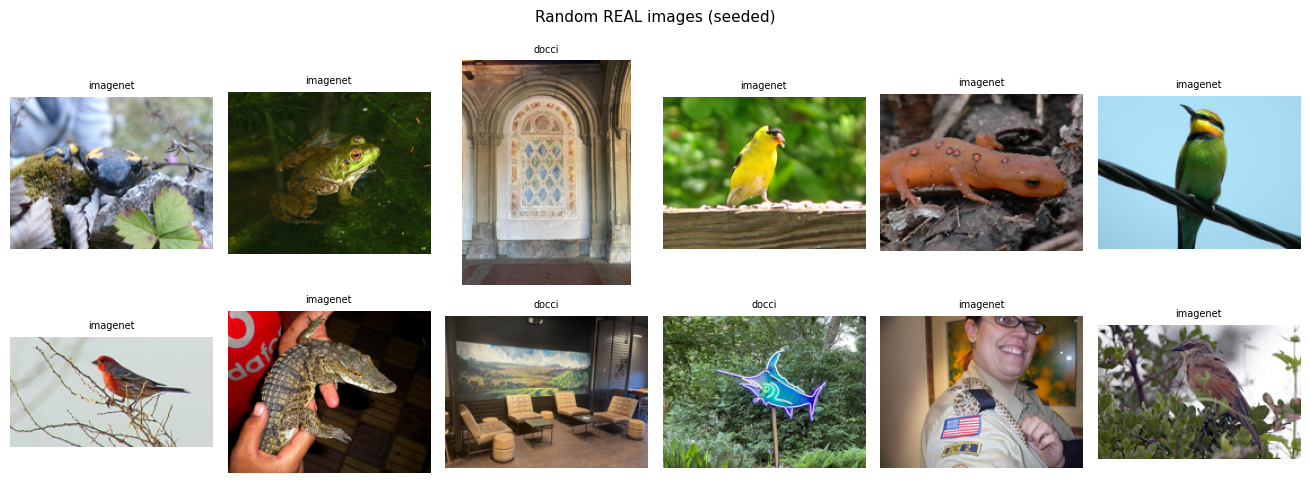

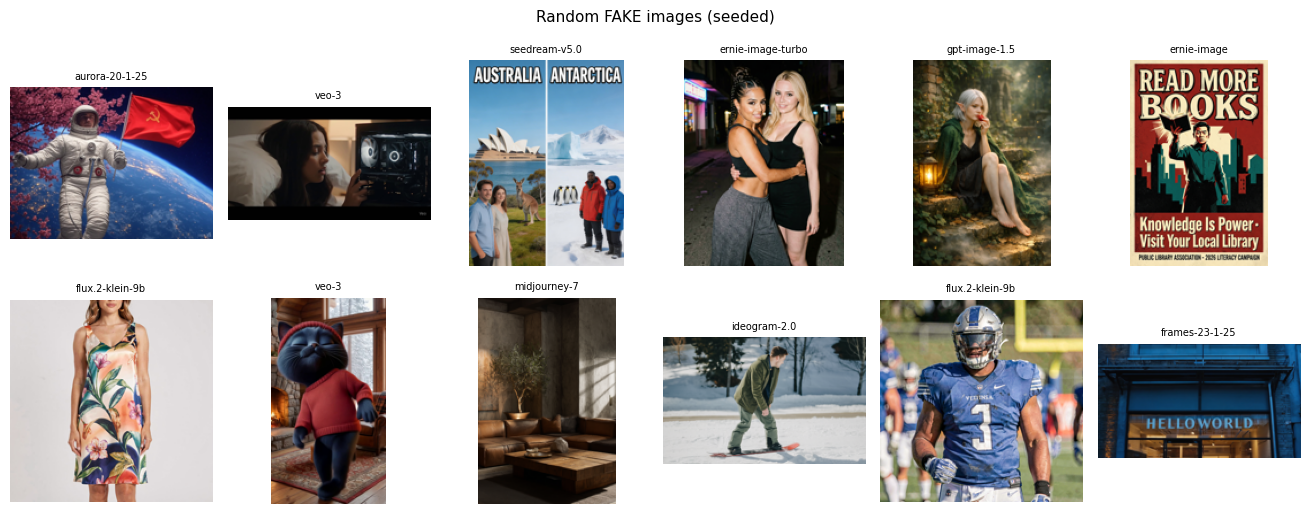

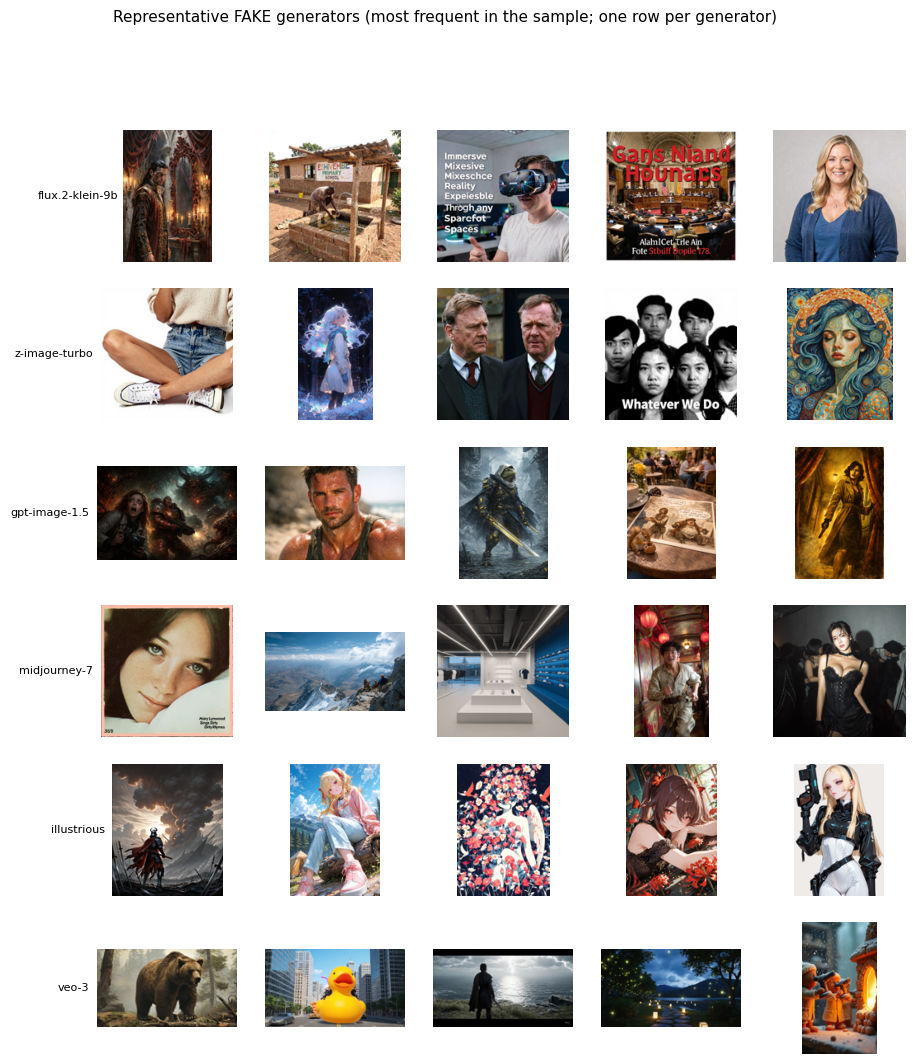

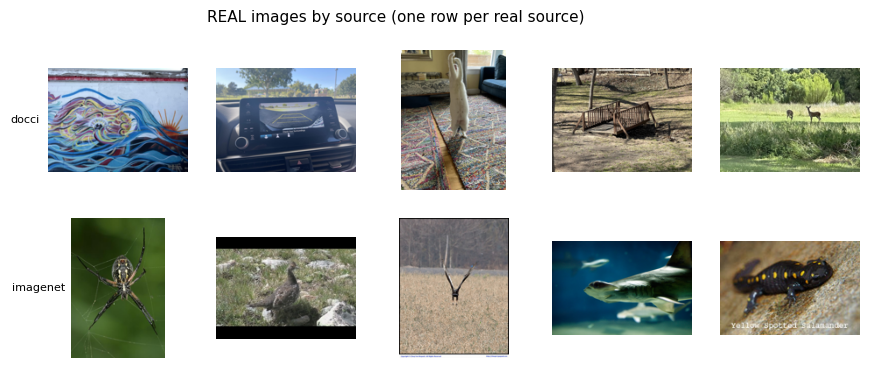

In [8]:
# ============================== SECTION 6 — contact sheets ==============================
def load_thumb(path, size=180):
    try:
        with Image.open(path) as im:
            try:
                im.draft("RGB", (size * 2, size * 2))     # fast JPEG downscale; harmless if unsupported
            except Exception:
                pass
            im = im.convert("RGB")
            im.thumbnail((size, size))
            return im.copy()
    except Exception:
        return None


def contact_sheet(rows_df, ncols, title):
    n = len(rows_df)
    if n == 0:
        print(f"[skip] {title}: no images")
        return
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(2.2 * ncols, 2.3 * nrows + 0.6), squeeze=False)
    for ax in axes.ravel():
        ax.axis("off")
    for ax, (_, r) in zip(axes.ravel(), rows_df.iterrows()):
        im = load_thumb(r["file_path"])
        if im is not None:
            ax.imshow(im)
        ax.set_title(str(r["source_group"])[:22], fontsize=7)
    fig.suptitle(title, fontsize=11)
    plt.tight_layout()
    plt.show()


N_GRID = 12
contact_sheet(cleaned_df[cleaned_df["label"] == "real"].sample(min(N_GRID, int((cleaned_df["label"] == "real").sum())),
                                                               random_state=SEED),
              6, "Random REAL images (seeded)")
contact_sheet(cleaned_df[cleaned_df["label"] == "fake"].sample(min(N_GRID, int((cleaned_df["label"] == "fake").sum())),
                                                               random_state=SEED),
              6, "Random FAKE images (seeded)")

# representative generators: the most frequent ones (up to 6), 5 images each
_top_models = cleaned_df[cleaned_df["label"] == "fake"]["source_group"].value_counts().index[:6]
if len(_top_models):
    n_per = 5
    fig, axes = plt.subplots(len(_top_models), n_per, figsize=(2.0 * n_per + 1.6, 2.0 * len(_top_models)), squeeze=False)
    for ax in axes.ravel():
        ax.axis("off")
    for ri, m in enumerate(_top_models):
        sub = cleaned_df[(cleaned_df["label"] == "fake") & (cleaned_df["source_group"] == m)]
        sub = sub.sample(min(n_per, len(sub)), random_state=SEED)
        for ci, (_, r) in enumerate(sub.iterrows()):
            im = load_thumb(r["file_path"], 160)
            if im is not None:
                axes[ri, ci].imshow(im)
        axes[ri, 0].text(-0.06, 0.5, str(m)[:24], transform=axes[ri, 0].transAxes, ha="right", va="center", fontsize=8)
    fig.suptitle("Representative FAKE generators (most frequent in the sample; one row per generator)", fontsize=11)
    fig.subplots_adjust(left=0.2)
    plt.show()

# real sources
_real_models = cleaned_df[cleaned_df["label"] == "real"]["source_group"].value_counts().index[:3]
if len(_real_models):
    n_per = 5
    fig, axes = plt.subplots(len(_real_models), n_per, figsize=(2.0 * n_per + 1.6, 2.0 * len(_real_models)), squeeze=False)
    for ax in axes.ravel():
        ax.axis("off")
    for ri, m in enumerate(_real_models):
        sub = cleaned_df[(cleaned_df["label"] == "real") & (cleaned_df["source_group"] == m)]
        sub = sub.sample(min(n_per, len(sub)), random_state=SEED)
        for ci, (_, r) in enumerate(sub.iterrows()):
            im = load_thumb(r["file_path"], 160)
            if im is not None:
                axes[ri, ci].imshow(im)
        axes[ri, 0].text(-0.06, 0.5, str(m)[:24], transform=axes[ri, 0].transAxes, ha="right", va="center", fontsize=8)
    fig.suptitle("REAL images by source (one row per real source)", fontsize=11)
    fig.subplots_adjust(left=0.2)
    plt.show()

## SECTION 7 — Metadata shortcut analysis (dataset-bias diagnostic, **not** detector training)

**Question:** can trivial, non-visual metadata — `width`, `height`, `aspect_ratio`, `file_size_bytes`, `format`, `channels` — separate real from fake images?
If yes, a real detector could learn those cues instead of genuine synthesis artefacts, and the data would need normalisation before detector training.

**Method.** A depth-limited, class-balanced decision tree (max depth 3, `min_samples_leaf=20`), evaluated three ways so that nothing is scored on data it was fitted on:

1. **Stratified hold-out** (70 / 30) -> balanced accuracy, confusion matrix, ROC-AUC, readable tree rules.
2. **Stratified 5-fold cross-validation** (pooled out-of-fold predictions).
3. **Source-grouped cross-validation** (`StratifiedGroupKFold` grouped by `source_group`): each fold's test set contains generators / real sources that the tree has *never seen*, which is the OOD-flavoured version of the question.

Exact duplicates were removed in Section 4, which prevents byte-identical images from appearing on both sides of a split. Near-duplicates are not checked (see Section 10).
Balanced accuracy of 0.5 means chance. The thresholds used for wording below (>= 0.85 strong, >= 0.65 moderate, otherwise weak) are interpretive rules of thumb, not statistical tests.

=== 1. Stratified hold-out (70/30), depth-3 tree on ALL metadata features ===
balanced accuracy: 0.944 | ROC-AUC: 0.970
confusion matrix (rows = true [real, fake], cols = predicted [real, fake]):
           pred real  pred fake
true real        437         13
true fake         37        413

Learned tree rules (training data only):
|--- num__height <= 597.00
|   |--- num__width <= 595.00
|   |   |--- num__aspect_ratio <= 0.67
|   |   |   |--- class: 0
|   |   |--- num__aspect_ratio >  0.67
|   |   |   |--- class: 0
|   |--- num__width >  595.00
|   |   |--- num__file_size_bytes <= 81089.50
|   |   |   |--- class: 0
|   |   |--- num__file_size_bytes >  81089.50
|   |   |   |--- class: 0
|--- num__height >  597.00
|   |--- num__width <= 1472.00
|   |   |--- num__file_size_bytes <= 96469.00
|   |   |   |--- class: 1
|   |   |--- num__file_size_bytes >  96469.00
|   |   |   |--- class: 1
|   |--- num__width >  1472.00
|   |   |--- num__file_size_bytes <= 1307327.50
|   |   |   |--- class: 

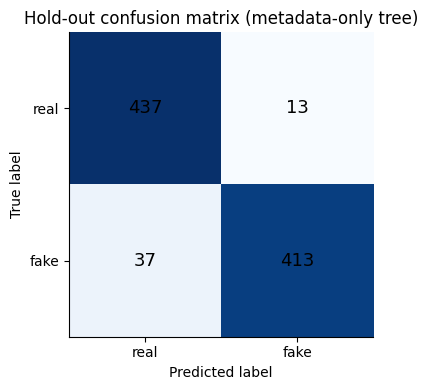


=== 2. Stratified 5-fold CV (pooled out-of-fold) ===
balanced accuracy: 0.941 | ROC-AUC: 0.969

=== 3. Source-grouped CV over 22 source groups (test folds contain UNSEEN generators/sources) ===
balanced accuracy: 0.523 | ROC-AUC: 0.500

Out-of-fold accuracy of the metadata tree per group (stratified CV):
label      source_group  oof_accuracy   n
 fake    aurora-20-1-25         1.000  23
 fake       ernie-image         1.000  32
 fake ernie-image-turbo         1.000  60
 fake   flux.2-klein-9b         1.000 168
 fake    frames-23-1-25         1.000  22
 fake   halfmoon-4-4-25         1.000  15
 fake        recraft-v2         1.000  20
 fake      ideogram-2.0         1.000  19
 fake    lumina-17-2-25         1.000  32
 fake      midjourney-7         0.994 167
 real             docci         0.984 750
 fake     z-image-turbo         0.976 167
 fake            sora-2         0.950  40
 real          imagenet         0.944 750
 fake       gpt-image-2         0.923  39
 fake     gpt-image-1

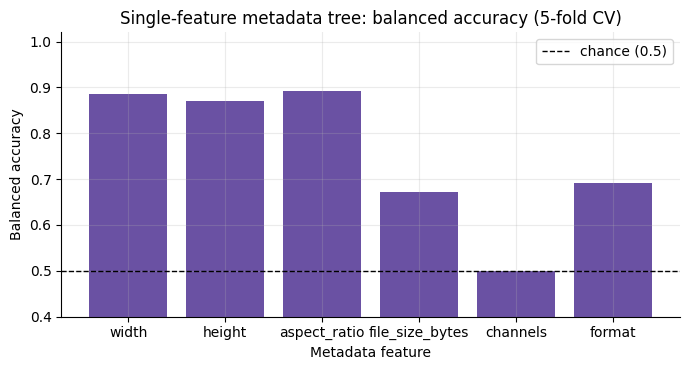


Single-feature balanced accuracy: {'width': 0.887, 'height': 0.87, 'aspect_ratio': 0.893, 'file_size_bytes': 0.672, 'channels': 0.5, 'format': 0.691}

----------------------------------------------------------------------
INTERPRETATION (generated from the numbers above)
----------------------------------------------------------------------
Simple metadata separates real from fake strongly in this sample, which suggests that the dataset contains source-specific metadata cues (resolution / aspect ratio / file size / format). A detector trained on raw files could exploit these shortcuts, so preprocessing normalisation (fixed resize/crop, common re-encoding, stripped metadata) is advisable before detector training.
Hold-out vs source-grouped balanced accuracy differ by +0.422: a large positive gap would mean the cues are tied to specific generators/sources seen in training; a small gap would mean they transfer to unseen sources.


In [9]:
# ============================== SECTION 7 — metadata shortcut diagnostic ==============================
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.model_selection import StratifiedKFold, StratifiedGroupKFold, train_test_split
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, roc_auc_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

NUM_FEATURES = ["width", "height", "aspect_ratio", "file_size_bytes", "channels"]
CAT_FEATURES = ["format"]
TREE_DEPTH, MIN_LEAF = 3, 20

meta_results = {"ok": False, "holdout_ba": None, "holdout_auc": None, "holdout_cm": None, "cv_ba": None, "cv_auc": None,
                "group_ba": None, "group_auc": None, "single_feature_ba": {}, "top_feature": None, "top_feature_ba": None,
                "level": None, "n_rows": 0}

meta_df = cleaned_df.dropna(subset=NUM_FEATURES).copy().reset_index(drop=True)
meta_df["format"] = meta_df["format"].fillna("UNKNOWN").astype(str)
y_meta = (meta_df["label"] == "fake").astype(int).to_numpy()
meta_results["n_rows"] = len(meta_df)
_min_class = int(min((y_meta == 0).sum(), (y_meta == 1).sum())) if len(y_meta) else 0


def build_pipe(num, cat):
    transformers = []
    if num:
        transformers.append(("num", "passthrough", num))
    if cat:
        transformers.append(("cat", OneHotEncoder(handle_unknown="ignore"), cat))
    prep = ColumnTransformer(transformers, sparse_threshold=0.0)
    tree = DecisionTreeClassifier(max_depth=TREE_DEPTH, min_samples_leaf=MIN_LEAF, class_weight="balanced",
                                  random_state=SEED)
    return Pipeline([("prep", prep), ("tree", tree)])


def safe_auc(y_true, score):
    try:
        if len(np.unique(y_true)) == 2:
            return float(roc_auc_score(y_true, score))
    except Exception:
        pass
    return None


def pooled_cv(X, y, splitter, num, cat, groups=None):
    # Fit on each training fold, predict the held-out fold, pool predictions, then score once.
    yt, yp, ys, te_all = [], [], [], []
    for tr, te in splitter.split(X, y, groups):
        if len(np.unique(y[tr])) < 2 or len(te) == 0:
            continue
        pipe = build_pipe(num, cat)
        pipe.fit(X.iloc[tr], y[tr])
        yp.extend(pipe.predict(X.iloc[te]).tolist())
        ys.extend(pipe.predict_proba(X.iloc[te])[:, 1].tolist())
        yt.extend(y[te].tolist())
        te_all.extend(te.tolist())
    if not yt:
        return None
    yt, yp, ys = np.array(yt), np.array(yp), np.array(ys)
    return {"ba": float(balanced_accuracy_score(yt, yp)), "auc": safe_auc(yt, ys),
            "cm": confusion_matrix(yt, yp, labels=[0, 1]), "te_idx": np.array(te_all), "pred": yp}


if _min_class < 10:
    print(f"[skip] metadata diagnostic: smallest class has only {_min_class} usable rows (need >= 10).")
else:
    X_meta = meta_df[NUM_FEATURES + CAT_FEATURES]
    all_num, all_cat = NUM_FEATURES, CAT_FEATURES

    # ---- 1. stratified hold-out ----
    Xtr, Xte, ytr, yte = train_test_split(X_meta, y_meta, test_size=0.3, stratify=y_meta, random_state=SEED)
    pipe_h = build_pipe(all_num, all_cat).fit(Xtr, ytr)
    pred_h = pipe_h.predict(Xte)
    prob_h = pipe_h.predict_proba(Xte)[:, 1]
    meta_results["holdout_ba"] = float(balanced_accuracy_score(yte, pred_h))
    meta_results["holdout_auc"] = safe_auc(yte, prob_h)
    meta_results["holdout_cm"] = confusion_matrix(yte, pred_h, labels=[0, 1])

    print("=== 1. Stratified hold-out (70/30), depth-3 tree on ALL metadata features ===")
    print("balanced accuracy:", fmt(meta_results["holdout_ba"]), "| ROC-AUC:", fmt(meta_results["holdout_auc"]))
    print("confusion matrix (rows = true [real, fake], cols = predicted [real, fake]):")
    print(pd.DataFrame(meta_results["holdout_cm"], index=["true real", "true fake"], columns=["pred real", "pred fake"]).to_string())
    try:
        _names = pipe_h.named_steps["prep"].get_feature_names_out()
        print("\nLearned tree rules (training data only):")
        print(export_text(pipe_h.named_steps["tree"], feature_names=[str(n) for n in _names]))
    except Exception as e:
        print("[warn] could not print tree rules:", e)

    fig, ax = plt.subplots(figsize=(4.6, 4))
    cm = meta_results["holdout_cm"]
    ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["real", "fake"])
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["real", "fake"])
    for i_ in range(2):
        for j_ in range(2):
            ax.text(j_, i_, str(cm[i_, j_]), ha="center", va="center", color="black", fontsize=13)
    ax.grid(False)
    ax.set_title("Hold-out confusion matrix (metadata-only tree)")
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    plt.tight_layout()
    plt.show()

    # ---- 2. stratified k-fold ----
    k = int(min(5, _min_class))
    res_cv = pooled_cv(X_meta, y_meta, StratifiedKFold(n_splits=k, shuffle=True, random_state=SEED), all_num, all_cat)
    if res_cv:
        meta_results["cv_ba"], meta_results["cv_auc"] = res_cv["ba"], res_cv["auc"]
    print(f"\n=== 2. Stratified {k}-fold CV (pooled out-of-fold) ===")
    print("balanced accuracy:", fmt(meta_results["cv_ba"]), "| ROC-AUC:", fmt(meta_results["cv_auc"]))

    # ---- 3. source-grouped k-fold (unseen generators / sources in every test fold) ----
    groups = meta_df["source_group"].to_numpy()
    n_groups = len(np.unique(groups))
    res_g = None
    if n_groups >= 3:
        try:
            kg = int(min(5, n_groups))
            res_g = pooled_cv(X_meta, y_meta, StratifiedGroupKFold(n_splits=kg, shuffle=True, random_state=SEED),
                              all_num, all_cat, groups=groups)
        except Exception as e:
            print("[warn] grouped CV failed:", type(e).__name__, e)
    if res_g:
        meta_results["group_ba"], meta_results["group_auc"] = res_g["ba"], res_g["auc"]
    print(f"\n=== 3. Source-grouped CV over {n_groups} source groups (test folds contain UNSEEN generators/sources) ===")
    print("balanced accuracy:", fmt(meta_results["group_ba"]), "| ROC-AUC:", fmt(meta_results["group_auc"]))

    # ---- per-group behaviour from the stratified CV out-of-fold predictions ----
    if res_cv:
        _oof = pd.DataFrame({"source_group": groups[res_cv["te_idx"]], "label": meta_df["label"].to_numpy()[res_cv["te_idx"]],
                             "pred_fake": res_cv["pred"]})
        _oof["correct"] = ((_oof["label"] == "fake").astype(int) == _oof["pred_fake"]).astype(int)
        per_group_acc = (_oof.groupby(["label", "source_group"])["correct"].agg(["mean", "size"])
                         .rename(columns={"mean": "oof_accuracy", "size": "n"}).round(3).reset_index())
        print("\nOut-of-fold accuracy of the metadata tree per group (stratified CV):")
        print(per_group_acc.sort_values("oof_accuracy", ascending=False).to_string(index=False))

    # ---- single-feature ablation ----
    single = {}
    for f in NUM_FEATURES + CAT_FEATURES:
        r_ = pooled_cv(X_meta, y_meta, StratifiedKFold(n_splits=k, shuffle=True, random_state=SEED),
                       [f] if f in NUM_FEATURES else [], [f] if f in CAT_FEATURES else [])
        single[f] = r_["ba"] if r_ else None
    meta_results["single_feature_ba"] = single
    _valid = {f: v for f, v in single.items() if v is not None}
    if _valid:
        meta_results["top_feature"] = max(_valid, key=_valid.get)
        meta_results["top_feature_ba"] = _valid[meta_results["top_feature"]]
        fig, ax = plt.subplots(figsize=(7, 3.8))
        names_, vals_ = list(_valid.keys()), list(_valid.values())
        ax.bar(names_, vals_, color="#6a51a3")
        ax.axhline(0.5, color="black", ls="--", lw=1, label="chance (0.5)")
        ax.set_ylim(0.4, 1.02)
        ax.set_title(f"Single-feature metadata tree: balanced accuracy ({k}-fold CV)")
        ax.set_xlabel("Metadata feature")
        ax.set_ylabel("Balanced accuracy")
        ax.legend()
        plt.tight_layout()
        plt.show()
        print("\nSingle-feature balanced accuracy:", {f: round(v, 3) for f, v in _valid.items()})

    meta_results["ok"] = True
    _ref = meta_results["holdout_ba"] if meta_results["holdout_ba"] is not None else meta_results["cv_ba"]
    if _ref is not None:
        meta_results["level"] = "strong" if _ref >= 0.85 else ("moderate" if _ref >= 0.65 else "weak")
    print("\n" + "-" * 70)
    print("INTERPRETATION (generated from the numbers above)")
    print("-" * 70)
    if meta_results["level"] == "strong":
        print("Simple metadata separates real from fake strongly in this sample, which suggests that the dataset contains "
              "source-specific metadata cues (resolution / aspect ratio / file size / format). A detector trained on "
              "raw files could exploit these shortcuts, so preprocessing normalisation (fixed resize/crop, common "
              "re-encoding, stripped metadata) is advisable before detector training.")
    elif meta_results["level"] == "moderate":
        print("Simple metadata separates real from fake to a moderate degree in this sample. Some source-specific cues "
              "exist and could be partially exploited by a detector; normalising resolution and compression is advisable.")
    else:
        print("Simple metadata separates real from fake only weakly in this sample; this diagnostic does not reveal a "
              "strong shortcut. This does not rule out subtler cues (e.g. JPEG quantisation tables, colour profiles, "
              "content bias) that these six features cannot capture.")
    if meta_results["group_ba"] is not None and meta_results["holdout_ba"] is not None:
        _d = meta_results["holdout_ba"] - meta_results["group_ba"]
        print(f"Hold-out vs source-grouped balanced accuracy differ by {_d:+.3f}: "
              "a large positive gap would mean the cues are tied to specific generators/sources seen in training; "
              "a small gap would mean they transfer to unseen sources.")

## SECTION 8 — Generator / source analysis

Only **ground-truth dataset fields** (`model`, `type`, `release_date`) are used. No architecture family is asserted from the data. If a manual model-to-family mapping is wanted, fill `MANUAL_FAMILY_MAP` below; it is treated as an **external, manual annotation** and kept in a separate table, never mixed with dataset fields.

Unique fake generators in the cleaned sample : 20
Unique real-image sources (`model` of real)  : 2  -> ['docci', 'imagenet']

Fake images per generator with `type` and release date:
     source_group  n_images               type first_release  n_distinct_release_dates
  flux.2-klein-9b       168 base, image, video    2026-01-14                         3
     midjourney-7       167               base    2025-04-01                         1
      illustrious       167       image, video    2025-01-01                        16
    gpt-image-1.5       167       image, video    2025-12-01                         5
    z-image-turbo       167 base, image, video    2025-11-01                         7
            veo-3       154              video    2025-06-01                        10
    wan-video-2.5        90              video    2025-09-01                         8
       recraft-v3        68               base    2024-10-01                         1
ernie-image-turbo        60        

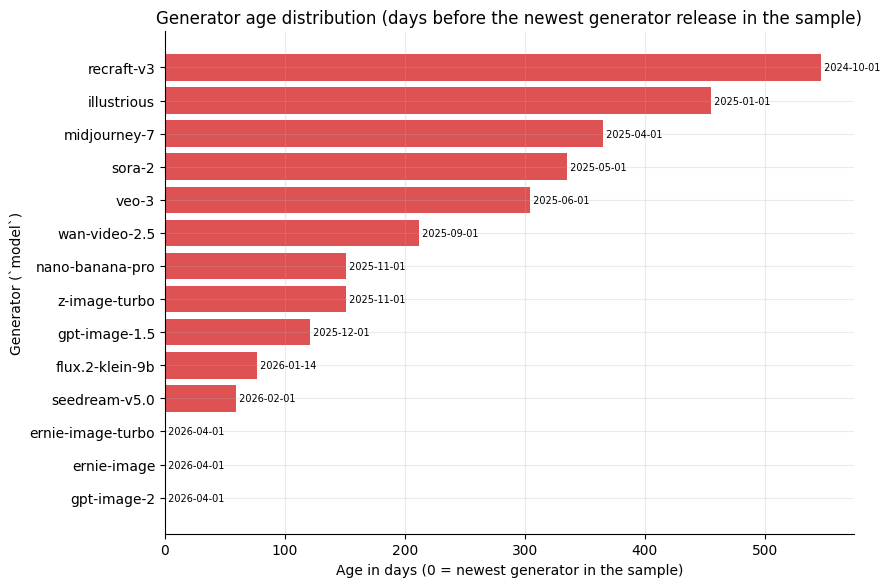


Newest generators represented in the sample:
     source_group               type first_release  n_images
ernie-image-turbo              image    2026-04-01        60
      gpt-image-2              image    2026-04-01        39
      ernie-image              image    2026-04-01        32
    seedream-v5.0              image    2026-02-01        29
  flux.2-klein-9b base, image, video    2026-01-14       168

Share of fake images from generators released within 365 days of the newest one: 75.6% (12 generators)

No manual architecture-family mapping was supplied; none is claimed.

Largest generator group: flux.2-klein-9b (168) | smallest: halfmoon-4-4-25 (15)


In [10]:
# ============================== SECTION 8 — generator / source analysis ==============================
MANUAL_FAMILY_MAP = {}   # OPTIONAL external/manual annotation, e.g. {"some-model-name": "diffusion"}. Empty by default.

fake_df = cleaned_df[cleaned_df["label"] == "fake"].copy()
real_df = cleaned_df[cleaned_df["label"] == "real"].copy()
n_fake_models = int(fake_df["source_group"].nunique())
n_real_sources = int(real_df["source_group"].nunique())


def _join_types(s):
    vals = sorted({str(v) for v in s.dropna()})
    return ", ".join(vals) if vals else "(missing)"


gen_table = (fake_df.groupby("source_group")
             .agg(n_images=("sample_id", "size"), type=("type", _join_types),
                  first_release=("release_date_parsed", "min"),
                  n_distinct_release_dates=("release_date_parsed", "nunique"))
             .reset_index().sort_values("n_images", ascending=False).reset_index(drop=True))

print(f"Unique fake generators in the cleaned sample : {n_fake_models}")
print(f"Unique real-image sources (`model` of real)  : {n_real_sources}  -> {sorted(real_df['source_group'].unique())}")
print("\nFake images per generator with `type` and release date:")
print(gen_table.to_string(index=False))
print("\nFake images by generator `type`:")
type_counts_fake = fake_df["type"].fillna("(missing)").value_counts()
print(type_counts_fake.to_string())
print("\nGenerator `type` x generator (number of images):")
print(pd.crosstab(fake_df["source_group"], fake_df["type"].fillna("(missing)")).to_string())
if (gen_table["n_distinct_release_dates"] > 1).any():
    print("\n[note] some generators carry more than one distinct release_date; the earliest is used as 'first_release'.")

release_min = release_max = None
newest_share = None
ref_date = None
_dates_ok = gen_table["first_release"].notna()
if _dates_ok.any():
    release_min, release_max = gen_table["first_release"].min(), gen_table["first_release"].max()
    ref_date = release_max
    gen_table["age_days"] = (ref_date - gen_table["first_release"]).dt.days
    print(f"\nRelease-date range of fake generators: {release_min.date()} -> {release_max.date()}")
    print(f"Generators with a release date: {int(_dates_ok.sum())}/{len(gen_table)}")
    print("\nGenerator age in days (relative to the NEWEST generator release date in this sample):")
    print(gen_table["age_days"].describe().round(1).to_string())

    _sorted = gen_table.dropna(subset=["first_release"]).sort_values("age_days", ascending=True)
    fig, ax = plt.subplots(figsize=(9, max(3.5, 0.32 * len(_sorted) + 1.5)))
    ax.barh(_sorted["source_group"].astype(str), _sorted["age_days"], color=FAKE_COLOR, alpha=0.8)
    for y_, (a_, d_) in enumerate(zip(_sorted["age_days"], _sorted["first_release"])):
        ax.text(a_, y_, f" {d_.date()}", va="center", fontsize=7)
    ax.set_title("Generator age distribution (days before the newest generator release in the sample)")
    ax.set_xlabel("Age in days (0 = newest generator in the sample)")
    ax.set_ylabel("Generator (`model`)")
    plt.tight_layout()
    plt.show()

    _newest = gen_table.dropna(subset=["first_release"]).sort_values("first_release", ascending=False).head(5)
    print("\nNewest generators represented in the sample:")
    print(_newest[["source_group", "type", "first_release", "n_images"]].to_string(index=False))
    _recent = gen_table[gen_table["age_days"] <= 365]
    newest_share = 100.0 * _recent["n_images"].sum() / gen_table["n_images"].sum()
    print(f"\nShare of fake images from generators released within 365 days of the newest one: {newest_share:.1f}% "
          f"({len(_recent)} generators)")
else:
    print("\n[note] no parsable generator release dates -> age analysis skipped.")

if MANUAL_FAMILY_MAP:
    _fam = fake_df.assign(manual_family=fake_df["source_group"].map(MANUAL_FAMILY_MAP).fillna("(unmapped)"))
    print("\nEXTERNAL / MANUAL model-family mapping (NOT a dataset field):")
    print(_fam["manual_family"].value_counts().to_string())
else:
    print("\nNo manual architecture-family mapping was supplied; none is claimed.")

if n_fake_models:
    _mx = gen_table.iloc[0]
    _mn = gen_table.iloc[-1]
    print(f"\nLargest generator group: {_mx['source_group']} ({_mx['n_images']}) | smallest: {_mn['source_group']} ({_mn['n_images']})")

## SECTION 9 — Lightweight forensic analysis (exploratory spectral profiling)

**One** CPU-friendly experiment: average **radial FFT magnitude** profiles.
For a small, seeded, generator-balanced sample (not all images): grayscale -> centre crop at **native resolution** (no resampling, so that resizing does not add its own spectral signature) -> Hann window -> 2-D FFT -> `log10(1 + |F|)` -> azimuthal average per radius.
Images whose shorter side is below the crop size are skipped (counted below).

> **This is exploratory forensic profiling.** Differences between curves may reflect resolution, JPEG/PNG compression, content and cropping as much as synthesis artefacts. **No claim of detector performance is made.**

FFT computed in 24.5s | crop 256x256 at native resolution
Profiles used (images) / skipped because shorter side < crop size:
  real (all sources)                       used= 192  skipped=   8
  fake (all generators)                    used= 200  skipped=   0
  fake: flux.2-klein-9b                    used=  40  skipped=   0
  fake: z-image-turbo                      used=  40  skipped=   0
  fake: gpt-image-1.5                      used=  40  skipped=   0
  fake: midjourney-7                       used=  40  skipped=   0
  real: docci                              used=  40  skipped=   0
  real: imagenet                           used=  37  skipped=   3


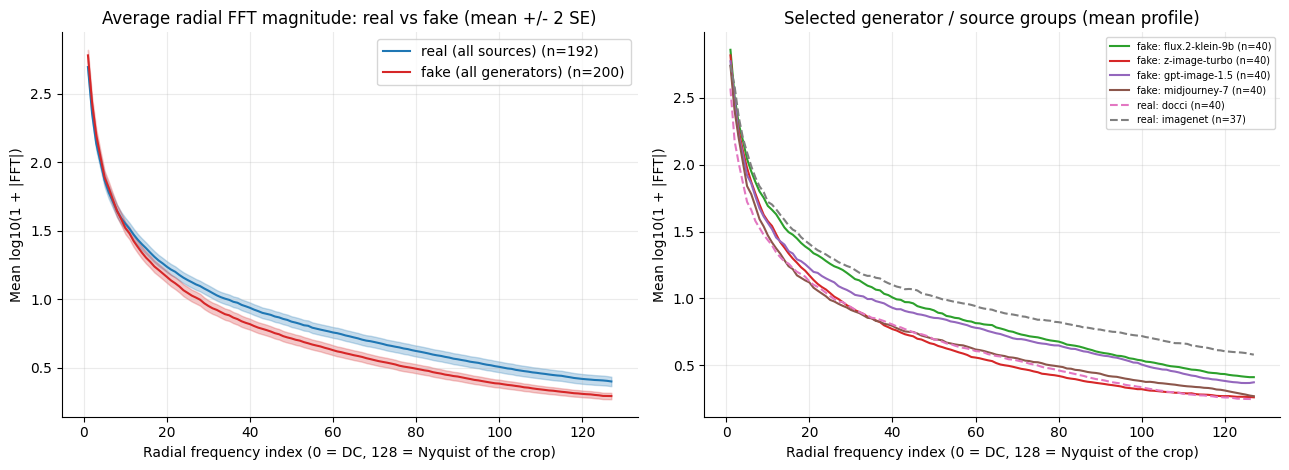


Mean log-magnitude per radial band:
                group   n  low (1-31)  mid (32-79)  high (80-127)
   real (all sources) 192      1.4638       0.8058         0.4980
fake (all generators) 200      1.4195       0.6813         0.3782

Fake minus real mean log-magnitude in the high band: -0.1198
Reminder: exploratory profiling only; differences may be driven by resolution, compression and content.


In [11]:
# ============================== SECTION 9 — radial FFT profiles ==============================
FFT_SIZE = 256
FFT_N_PER_LABEL = 200
FFT_N_PER_GROUP = 40
FFT_TOP_GROUPS = 4

_hann = np.hanning(FFT_SIZE)
_window = np.outer(_hann, _hann)
_yy, _xx = np.indices((FFT_SIZE, FFT_SIZE))
_rad = np.hypot(_yy - FFT_SIZE // 2, _xx - FFT_SIZE // 2).astype(int)
_rad_counts = np.bincount(_rad.ravel())
N_RAD = FFT_SIZE // 2


def radial_profile(path):
    # Returns a 1-D array (length N_RAD) or None if the image is too small / unreadable.
    try:
        with Image.open(path) as im:
            im = im.convert("L")
            w, h = im.size
            if min(w, h) < FFT_SIZE:
                return None
            left, top = (w - FFT_SIZE) // 2, (h - FFT_SIZE) // 2
            arr = np.asarray(im.crop((left, top, left + FFT_SIZE, top + FFT_SIZE)), dtype=np.float64) / 255.0
    except Exception:
        return None
    arr = (arr - arr.mean()) * _window
    mag = np.log10(1.0 + np.abs(np.fft.fftshift(np.fft.fft2(arr))))
    prof = np.bincount(_rad.ravel(), weights=mag.ravel()) / np.maximum(_rad_counts, 1)
    return prof[:N_RAD]


def balanced_pick(df_, n, seed):
    # Spread n picks as evenly as possible over source_group (water-filling), seeded.
    if len(df_) == 0:
        return df_
    counts = df_["source_group"].value_counts().to_dict()
    al = waterfill(counts, min(n, len(df_)))
    parts = [df_[df_["source_group"] == g].sample(k, random_state=seed) for g, k in sorted(al.items()) if k > 0]
    return pd.concat(parts) if parts else df_.iloc[0:0]


def profiles_for(df_):
    profs, skipped = [], 0
    for p in df_["file_path"]:
        r = radial_profile(p)
        if r is None:
            skipped += 1
        else:
            profs.append(r)
    return (np.vstack(profs) if profs else np.empty((0, N_RAD))), skipped


fft_summary = {"ok": False}
_t0 = time.time()
fft_groups = {}
skip_counts = {}
_pick_real = balanced_pick(cleaned_df[cleaned_df["label"] == "real"], FFT_N_PER_LABEL, SEED)
_pick_fake = balanced_pick(cleaned_df[cleaned_df["label"] == "fake"], FFT_N_PER_LABEL, SEED)
for name, sub in [("real (all sources)", _pick_real), ("fake (all generators)", _pick_fake)]:
    fft_groups[name], skip_counts[name] = profiles_for(sub)

_top_fake = cleaned_df[cleaned_df["label"] == "fake"]["source_group"].value_counts().index[:FFT_TOP_GROUPS]
for g in _top_fake:
    sub = cleaned_df[(cleaned_df["label"] == "fake") & (cleaned_df["source_group"] == g)]
    sub = sub.sample(min(FFT_N_PER_GROUP, len(sub)), random_state=SEED)
    fft_groups[f"fake: {g}"], skip_counts[f"fake: {g}"] = profiles_for(sub)
_top_real = cleaned_df[cleaned_df["label"] == "real"]["source_group"].value_counts().index[:2]
for g in _top_real:
    sub = cleaned_df[(cleaned_df["label"] == "real") & (cleaned_df["source_group"] == g)]
    sub = sub.sample(min(FFT_N_PER_GROUP, len(sub)), random_state=SEED)
    fft_groups[f"real: {g}"], skip_counts[f"real: {g}"] = profiles_for(sub)

print(f"FFT computed in {time.time() - _t0:.1f}s | crop {FFT_SIZE}x{FFT_SIZE} at native resolution")
print("Profiles used (images) / skipped because shorter side < crop size:")
for k_, v_ in fft_groups.items():
    print(f"  {k_:<40s} used={v_.shape[0]:>4d}  skipped={skip_counts[k_]:>4d}")

r_axis = np.arange(N_RAD)
_rk, _fk = "real (all sources)", "fake (all generators)"
if fft_groups[_rk].shape[0] >= 3 and fft_groups[_fk].shape[0] >= 3:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
    for name, color in [(_rk, REAL_COLOR), (_fk, FAKE_COLOR)]:
        P = fft_groups[name]
        m = P.mean(axis=0)
        se = P.std(axis=0, ddof=1) / np.sqrt(P.shape[0])
        axes[0].plot(r_axis[1:], m[1:], color=color, label=f"{name} (n={P.shape[0]})")
        axes[0].fill_between(r_axis[1:], (m - 2 * se)[1:], (m + 2 * se)[1:], color=color, alpha=0.25)
    axes[0].set_title("Average radial FFT magnitude: real vs fake (mean +/- 2 SE)")
    axes[0].set_xlabel("Radial frequency index (0 = DC, 128 = Nyquist of the crop)")
    axes[0].set_ylabel("Mean log10(1 + |FFT|)")
    axes[0].legend()
    cmap = plt.get_cmap("tab10")
    for i_, (name, P) in enumerate(fft_groups.items()):
        if name in (_rk, _fk) or P.shape[0] < 3:
            continue
        ls = "-" if name.startswith("fake") else "--"
        axes[1].plot(r_axis[1:], P.mean(axis=0)[1:], ls, color=cmap(i_ % 10), label=f"{name} (n={P.shape[0]})")
    axes[1].set_title("Selected generator / source groups (mean profile)")
    axes[1].set_xlabel("Radial frequency index (0 = DC, 128 = Nyquist of the crop)")
    axes[1].set_ylabel("Mean log10(1 + |FFT|)")
    axes[1].legend(fontsize=7)
    plt.tight_layout()
    plt.show()

    bands = {"low (1-31)": (1, 32), "mid (32-79)": (32, 80), "high (80-127)": (80, N_RAD)}
    band_rows = []
    for name in [_rk, _fk]:
        P = fft_groups[name]
        band_rows.append({"group": name, "n": P.shape[0], **{b: float(P[:, lo:hi].mean()) for b, (lo, hi) in bands.items()}})
    band_df = pd.DataFrame(band_rows).round(4)
    print("\nMean log-magnitude per radial band:")
    print(band_df.to_string(index=False))
    fft_summary = {"ok": True, "n_real": int(fft_groups[_rk].shape[0]), "n_fake": int(fft_groups[_fk].shape[0]),
                   "band_df": band_df,
                   "high_diff": float(band_df.loc[1, "high (80-127)"] - band_df.loc[0, "high (80-127)"])}
    print(f"\nFake minus real mean log-magnitude in the high band: {fft_summary['high_diff']:+.4f}")
    print("Reminder: exploratory profiling only; differences may be driven by resolution, compression and content.")
else:
    print("[skip] not enough images with shorter side >= crop size to build real/fake FFT profiles.")

## SECTION 10 — Dataset integrity / leakage checks

Checks **actually performed** here: exact-byte duplicates (MD5) overall and across labels; metadata-identical records with different bytes; uniqueness of sample IDs; uniqueness of any dataset-provided image path.
Checks **not performed**: perceptual / near-duplicate detection, overlap with the training split (the training split is not streamed), prompt-level overlap. Therefore this section cannot establish the absence of leakage in general.

In [12]:
# ============================== SECTION 10 — integrity & leakage checks ==============================
integrity = {}
dup_mask_all = raw_df.duplicated("md5", keep=False)
integrity["rows_in_md5_dup_groups_raw"] = int(dup_mask_all.sum())
integrity["md5_dup_groups_raw"] = int(raw_df.loc[dup_mask_all, "md5"].nunique())
integrity["extra_copies_raw"] = int(raw_df.duplicated("md5", keep="first").sum())
_lab_per_md5 = raw_df.groupby("md5")["label"].nunique()
integrity["md5_groups_across_labels_raw"] = int((_lab_per_md5 > 1).sum())
integrity["md5_groups_across_sources_raw"] = int((raw_df.groupby("md5")["source_group"].nunique() > 1).sum())
integrity["md5_dups_remaining_cleaned"] = int(cleaned_df.duplicated("md5", keep=False).sum())

_sig_cols = ["label", "source_group", "type", "release_date", "width", "height", "file_size_bytes"]
_sig = raw_df[_sig_cols].apply(lambda r: "|".join(str(v) for v in r), axis=1)
_sig_dup = _sig.duplicated(keep=False)
integrity["metadata_identical_rows"] = int(_sig_dup.sum())
integrity["metadata_identical_but_different_md5"] = int(
    raw_df.loc[_sig_dup].groupby(_sig[_sig_dup])["md5"].nunique().gt(1).sum())
integrity["sample_id_duplicates"] = int(raw_df["sample_id"].duplicated().sum())
if raw_df["dataset_path"].notna().any():
    integrity["dataset_path_duplicates"] = int(raw_df["dataset_path"].dropna().duplicated().sum())
else:
    integrity["dataset_path_duplicates"] = None

print("INTEGRITY CHECKS (raw sample unless stated)")
print("-" * 70)
print(f"Rows inside MD5-duplicate groups            : {integrity['rows_in_md5_dup_groups_raw']}")
print(f"MD5-duplicate groups                        : {integrity['md5_dup_groups_raw']}")
print(f"Extra copies (rows beyond the first)        : {integrity['extra_copies_raw']}")
print(f"MD5 groups spanning BOTH labels             : {integrity['md5_groups_across_labels_raw']}")
print(f"MD5 groups spanning >1 source/generator     : {integrity['md5_groups_across_sources_raw']}")
print(f"MD5 duplicates remaining in cleaned_df      : {integrity['md5_dups_remaining_cleaned']}")
print(f"Metadata-identical rows (label/source/type/date/size/bytes) : {integrity['metadata_identical_rows']}")
print(f"  ... of which with DIFFERENT image bytes (groups)          : {integrity['metadata_identical_but_different_md5']}")
print(f"Duplicate sample IDs                        : {integrity['sample_id_duplicates']}")
print(f"Duplicate dataset-provided image paths      : {fmt(integrity['dataset_path_duplicates'])}"
      + ("" if integrity["dataset_path_duplicates"] is not None else "  (no path information in the streamed rows)"))

print("\nNOT CHECKED: perceptual/near-duplicates, overlap with the training split, prompt-level overlap.")

print("\n--- Does the structure support OOD analysis? (derived from this sample only) ---")
print(f"* Distinct fake generators observed : {n_fake_models}")
print(f"* Distinct real sources observed    : {n_real_sources}")
print(f"* Generator `type` values observed  : {sorted(fake_df['type'].dropna().unique()) if fake_df['type'].notna().any() else '(none)'}")
if release_min is not None:
    print(f"* Generator release-date range       : {release_min.date()} -> {release_max.date()}")
print("* `model` / `type` / `release_date` are present per image, so results can be reported PER generator and PER source,")
print("  which is what an OOD / generalisation study needs (e.g. per-generator recall).")
print("* The claim that these generators and real sources are held out relative to the training split comes from the")
print("  dataset documentation; it was NOT verified here because the training split was not streamed.")

INTEGRITY CHECKS (raw sample unless stated)
----------------------------------------------------------------------
Rows inside MD5-duplicate groups            : 4
MD5-duplicate groups                        : 2
Extra copies (rows beyond the first)        : 2
MD5 groups spanning BOTH labels             : 0
MD5 groups spanning >1 source/generator     : 0
MD5 duplicates remaining in cleaned_df      : 0
Metadata-identical rows (label/source/type/date/size/bytes) : 4
  ... of which with DIFFERENT image bytes (groups)          : 0
Duplicate sample IDs                        : 0
Duplicate dataset-provided image paths      : 0

NOT CHECKED: perceptual/near-duplicates, overlap with the training split, prompt-level overlap.

--- Does the structure support OOD analysis? (derived from this sample only) ---
* Distinct fake generators observed : 20
* Distinct real sources observed    : 2
* Generator `type` values observed  : ['base', 'image', 'video']
* Generator release-date range       : 2024-10-0

## SECTION 11 — Comparison with Defactify

The **OpenFake column is computed from this notebook's sample**. The **Defactify column reproduces the qualitative characterisation from the project's earlier Defactify analysis and was not recomputed here** — teammates should verify those cells against the Defactify EDA notebook before publishing. OpenFake `core/test` is positioned as a **complementary OOD-oriented dataset**, not a replacement for any other project dataset.

In [13]:
# ============================== SECTION 11 — comparison table ==============================
_real_src_names = ", ".join(sorted(real_df["source_group"].unique())) if n_real_sources else "n/a"
_has_prompt = float(cleaned_df["prompt_available"].mean() * 100) if len(cleaned_df) else float("nan")
comparison_rows = [
    ("Role in the project",
     "Supplementary OOD / generalisation-oriented dataset (preliminary EDA)",
     "Earlier analysed dataset in the project's benchmark stack (verify against the Defactify EDA)"),
    ("Real / fake labels",
     f"Yes - binary `label` field (real={int((cleaned_df['label'] == 'real').sum())}, fake={int((cleaned_df['label'] == 'fake').sum())} in the cleaned sample)",
     "Yes - real vs AI-generated (verify exact label scheme)"),
    ("Generator metadata",
     "Per-image `model`, `type`, `release_date` (ground-truth fields)",
     "Generator identity available (verify exact fields)"),
    ("Generator diversity",
     f"{n_fake_models} distinct fake generators observed in this sample",
     "A smaller, fixed set of generators (verify count in the Defactify EDA)"),
    ("OOD properties",
     "Split designed for held-out generators / different real sources per the dataset documentation (not verified here)",
     "Not characterised as an OOD split in this comparison (verify)"),
    ("Real-image source diversity",
     f"{n_real_sources} real source value(s) observed: {_real_src_names}",
     "Typically a narrower real-image source (verify)"),
    ("Caption / prompt availability",
     f"`prompt` field present for {_has_prompt:.1f}% of cleaned rows; known prompt-image mismatch for some generators",
     "Captions available per the earlier analysis (verify)"),
    ("Known limitations",
     "Prompt-image mismatch; sample-based view only; metadata / resolution cues possible (see Section 7); only the test split was inspected",
     "See the Defactify EDA notebook"),
    ("Usefulness for Mad-Eye Moody Lens",
     "Stress-test of generalisation to unseen generators / sources; per-generator reporting; shortcut diagnostics",
     "Core benchmark for in-distribution comparison (verify)"),
]
comparison_df = pd.DataFrame(comparison_rows, columns=["Aspect", "OpenFake core/test (this notebook)",
                                                       "Defactify (from earlier project analysis - verify)"])


def to_md_table(df_):
    cols = list(df_.columns)
    lines = ["| " + " | ".join(cols) + " |", "|" + "|".join(["---"] * len(cols)) + "|"]
    for _, r in df_.iterrows():
        lines.append("| " + " | ".join(str(r[c]).replace("|", "/").replace("\n", " ") for c in cols) + " |")
    return "\n".join(lines)


display(Markdown(to_md_table(comparison_df)))
display(Markdown("*Defactify cells were not recomputed in this notebook. OpenFake `core/test` is a complementary OOD-oriented "
                 "dataset and does not replace the other datasets in the project.*"))

| Aspect | OpenFake core/test (this notebook) | Defactify (from earlier project analysis - verify) |
|---|---|---|
| Role in the project | Supplementary OOD / generalisation-oriented dataset (preliminary EDA) | Earlier analysed dataset in the project's benchmark stack (verify against the Defactify EDA) |
| Real / fake labels | Yes - binary `label` field (real=1500, fake=1498 in the cleaned sample) | Yes - real vs AI-generated (verify exact label scheme) |
| Generator metadata | Per-image `model`, `type`, `release_date` (ground-truth fields) | Generator identity available (verify exact fields) |
| Generator diversity | 20 distinct fake generators observed in this sample | A smaller, fixed set of generators (verify count in the Defactify EDA) |
| OOD properties | Split designed for held-out generators / different real sources per the dataset documentation (not verified here) | Not characterised as an OOD split in this comparison (verify) |
| Real-image source diversity | 2 real source value(s) observed: docci, imagenet | Typically a narrower real-image source (verify) |
| Caption / prompt availability | `prompt` field present for 100.0% of cleaned rows; known prompt-image mismatch for some generators | Captions available per the earlier analysis (verify) |
| Known limitations | Prompt-image mismatch; sample-based view only; metadata / resolution cues possible (see Section 7); only the test split was inspected | See the Defactify EDA notebook |
| Usefulness for Mad-Eye Moody Lens | Stress-test of generalisation to unseen generators / sources; per-generator reporting; shortcut diagnostics | Core benchmark for in-distribution comparison (verify) |

*Defactify cells were not recomputed in this notebook. OpenFake `core/test` is a complementary OOD-oriented dataset and does not replace the other datasets in the project.*

## SECTION 12 — Final findings (generated from the notebook output)

The text below is **assembled by code from the variables computed in Sections 2–10**. No figure is typed in by hand. Wording is deliberately cautious ("the sample suggests…"): EDA on a sample cannot prove generalisation, and nothing here evaluates a detector.

In [14]:
# ============================== SECTION 12 — evidence-based findings ==============================
def _counts_str(series, top=None):
    vc = series.value_counts()
    if top:
        vc = vc.head(top)
    return ", ".join(f"{k} ({v})" for k, v in vc.items()) if len(vc) else "n/a"


n_real_clean = int((cleaned_df["label"] == "real").sum())
n_fake_clean = int((cleaned_df["label"] == "fake").sum())
_med = cleaned_df.assign(mp=cleaned_df["width"] * cleaned_df["height"] / 1e6).groupby("label")["mp"].median()
_medsize = (cleaned_df["file_size_bytes"] / 1024).groupby(cleaned_df["label"]).median()
_fmts = pd.crosstab(cleaned_df["format"].fillna("(missing)"), cleaned_df["label"])

F = {k: [] for k in ["Key findings", "Data-quality findings", "Metadata-shortcut findings", "OOD/generalization relevance",
                      "Practical preprocessing implications", "Suitability for Mad-Eye Moody Lens", "Limitations",
                      "Recommended role in the overall benchmark stack"]}

# ---- key findings ----
F["Key findings"] += [
    f"The streamed scan covered {fmt(rows_scanned)} rows of `{DATASET_ID}` / `{CONFIG}` / `{SPLIT}` (status: {scan_status}); "
    f"{fmt(len(selected_records))} images were selected (target {fmt(TARGET_TOTAL)}) and {fmt(n_clean)} remained after cleaning "
    f"(real {fmt(n_real_clean)}, fake {fmt(n_fake_clean)}).",
    f"The sample contains {fmt(n_fake_models)} distinct fake generators and {fmt(n_real_sources)} real-image source value(s) "
    f"({_real_src_names}).",
    f"Fake images per generator range from {fmt(int(gen_table['n_images'].min())) if n_fake_models else 'n/a'} to "
    f"{fmt(int(gen_table['n_images'].max())) if n_fake_models else 'n/a'} in the cleaned sample, "
    "which follows from the automatic water-filling allocation and what was available in the scanned portion.",
    f"Generator `type` values in the sample: {_counts_str(fake_df['type'].fillna('(missing)'))}.",
]
if release_min is not None:
    F["Key findings"].append(f"Generator release dates in the sample span {release_min.date()} to {release_max.date()}; "
                             f"{fmt(newest_share, pct=True)} of fake images come from generators released within 365 days of the newest one.")
else:
    F["Key findings"].append("No parsable generator release dates were found, so generator age could not be analysed.")
if len(_med) == 2:
    F["Key findings"].append(f"Median resolution is {_med.get('real', float('nan')):.2f} MP for real and {_med.get('fake', float('nan')):.2f} MP "
                             f"for fake images; median file size is {_medsize.get('real', float('nan')):.0f} KB (real) vs "
                             f"{_medsize.get('fake', float('nan')):.0f} KB (fake).")
F["Key findings"].append("File formats by label in the cleaned sample: " +
                         "; ".join(f"{idx}: real={int(r.get('real', 0))}, fake={int(r.get('fake', 0))}" for idx, r in _fmts.iterrows()) + ".")

# ---- data quality ----
F["Data-quality findings"] += [
    f"{fmt(n_raw)} sampled rows -> {fmt(n_clean)} retained ({retention_pct:.2f}% retention).",
    f"Unreadable images: {fmt(n_unreadable)}; invalid dimensions: {fmt(n_invalid_dims)}; invalid labels among sampled rows: "
    f"{fmt(n_invalid_label_rows_sampled)} (invalid-label rows met during the scan and never sampled: {fmt(n_invalid_label_scan)}).",
    f"Exact duplicate extra copies (MD5): {fmt(n_dup_extra)}; rows in label-conflicting duplicate groups: {fmt(n_label_conflict)}.",
    f"Flagged but kept: missing `model` {fmt(n_missing_model)}, tiny images {fmt(n_tiny)}, missing `type` {fmt(n_missing_type)}, "
    f"missing `release_date` {fmt(n_missing_date)}, unparsable `release_date` {fmt(n_bad_date)}.",
    "`prompt` was not used for quality or label validation because of the reported prompt-image mismatch for some generators.",
]
if n_reencoded:
    F["Data-quality findings"].append(f"{fmt(n_reencoded)} images had to be re-encoded by the notebook, so their file format / size columns are not original.")

# ---- metadata shortcut ----
if meta_results["ok"]:
    F["Metadata-shortcut findings"] += [
        f"A depth-{TREE_DEPTH} decision tree on width, height, aspect ratio, file size, format and channels reached a hold-out balanced accuracy of "
        f"{fmt(meta_results['holdout_ba'])} (ROC-AUC {fmt(meta_results['holdout_auc'])}); stratified CV gave {fmt(meta_results['cv_ba'])}; "
        f"source-grouped CV (unseen generators/sources in test folds) gave {fmt(meta_results['group_ba'])}. Chance level is 0.5.",
        f"The single most informative feature was `{meta_results['top_feature']}` (balanced accuracy {fmt(meta_results['top_feature_ba'])} on its own).",
    ]
    if meta_results["level"] == "strong":
        F["Metadata-shortcut findings"].append("The analysis indicates strong source-specific metadata cues: simple metadata separates real from fake in this sample, "
                                               "so preprocessing normalisation is likely required before detector training.")
    elif meta_results["level"] == "moderate":
        F["Metadata-shortcut findings"].append("The analysis indicates moderate metadata cues: some separation is possible from simple metadata, so normalisation is advisable.")
    else:
        F["Metadata-shortcut findings"].append("The analysis indicates only weak separation from these six metadata features; this does not exclude subtler cues such as compression tables or content bias.")
else:
    F["Metadata-shortcut findings"].append("The metadata-shortcut diagnostic could not be completed on this sample (see Section 7 output).")

# ---- OOD ----
F["OOD/generalization relevance"] += [
    f"This dataset provides per-image generator (`model`), generator `type` and `release_date`, which allows per-generator reporting; "
    f"the sample contains {fmt(n_fake_models)} fake generators and {fmt(n_real_sources)} real source value(s).",
    "According to the dataset documentation the split is meant to contain unseen generators and different real sources; this was not verified here because the "
    "training split was not inspected. EDA on a sample cannot prove that a model will generalise.",
]
if meta_results["ok"] and meta_results["group_ba"] is not None and meta_results["holdout_ba"] is not None:
    F["OOD/generalization relevance"].append(
        f"Metadata cues measured with source-grouped CV ({fmt(meta_results['group_ba'])}) versus random hold-out ({fmt(meta_results['holdout_ba'])}) "
        "indicate how much of any shortcut is tied to specific sources.")

# ---- preprocessing ----
F["Practical preprocessing implications"] += [
    "Use a common preprocessing pipeline for both classes (fixed-size crop/resize, consistent colour mode, and ideally a common re-encoding) so file format, resolution and compression do not act as labels.",
    "Report results per generator and per real source, not only pooled, so that weak groups are visible.",
    "Keep exact-duplicate removal (MD5) and consider perceptual-hash de-duplication, which was not performed here.",
]
if meta_results["level"] in ("strong", "moderate"):
    F["Practical preprocessing implications"].append("Because metadata separated the classes, compare detector results with and without normalisation to check for shortcut learning.")

# ---- suitability ----
F["Suitability for Mad-Eye Moody Lens"] += [
    f"The sample suggests the dataset is usable for a CPU-friendly streaming workflow: {fmt(retention_pct, pct=True)} of sampled rows passed validation.",
    "It offers generator-level labels and release dates that fit an evaluation-oriented role. Suitability for final benchmarking still depends on the preprocessing and leakage caveats above.",
]

# ---- limitations ----
F["Limitations"] += [
    f"Only a bounded sample was analysed ({fmt(rows_scanned)} scanned rows, {fmt(len(selected_records))} selected); group sizes depend on what the shuffled stream delivered, and the shuffle is approximate.",
    "Only the `test` split was inspected; train/test disjointness and leakage against the training split were not checked.",
    "Near-duplicate (perceptual) checks were not performed; only exact MD5 duplicates were examined.",
    "The prompt-image mismatch reported for some generators was neither measured nor corrected; `prompt` was used descriptively only.",
    "The metadata diagnostic uses six simple features and a shallow tree; the FFT profile is an exploratory, resolution- and compression-sensitive view and says nothing about detector performance.",
    "Real-source names are the values of `model` for real rows and depend on how the dataset encodes them.",
]

# ---- role ----
F["Recommended role in the overall benchmark stack"] += [
    "Use OpenFake `core/test` as a complementary OOD / generalisation stress-test alongside the project's other datasets, not as a replacement for them.",
    "Apply the preprocessing precautions above before using it for any detector evaluation.",
]

findings_md = "\n\n".join(f"### {sec}\n" + "\n".join(f"- {line}" for line in lines) for sec, lines in F.items())
display(Markdown(findings_md))

# ---- README-ready summary ----
readme_md = f"""## OpenFake `core/test` — preliminary dataset EDA (Mad-Eye Moody Lens)

**Dataset chosen:** `{DATASET_ID}`, config `{CONFIG}`, split `{SPLIT}` (streamed; never downloaded in full).

**Why it was chosen:** the split is documented as an out-of-distribution / generalisation split (held-out generators, different real sources) and carries per-image `model`, `type` and `release_date` metadata. It is used as a *supplementary* dataset that complements Defactify.

**Sampling method:** seeded streaming shuffle (seed {SEED}), bounded scan of {fmt(rows_scanned)} rows, per-group seeded reservoir sampling, then water-filling allocation of about {fmt(TARGET_REAL)} real and {fmt(TARGET_FAKE)} fake images across the observed real sources and fake generators. Final sample: {fmt(len(selected_records))} images; {fmt(n_clean)} after cleaning ({retention_pct:.2f}% retention).

**Major findings:** {fmt(n_fake_models)} fake generators and {fmt(n_real_sources)} real source value(s) observed; metadata-only tree balanced accuracy {fmt(meta_results['holdout_ba'])} (hold-out), {fmt(meta_results['cv_ba'])} (stratified CV), {fmt(meta_results['group_ba'])} (source-grouped CV) -> metadata shortcut level: {meta_results['level'] if meta_results['level'] else 'not assessed'}. Rows excluded for exact (MD5) duplication: {fmt(n_dup_extra + n_label_conflict)} (extra same-label copies: {fmt(n_dup_extra)}; label-conflicting duplicates: {fmt(n_label_conflict)}).

**Limitations:** sample-based; only the test split was inspected; no perceptual-duplicate or train-overlap checks; prompt-image mismatch not addressed; FFT profiling is exploratory only; nothing here evaluates a detector.

**Project relevance:** a complementary OOD-oriented stress-test dataset for Mad-Eye Moody Lens; per-generator reporting and resolution/compression normalisation are recommended before detector evaluation.
"""
print("README-ready summary and findings have been generated (displayed below and saved in Section 13).")

### Key findings
- The streamed scan covered 6,879 rows of `ComplexDataLab/OpenFake` / `core` / `test` (status: time limit reached); 3,000 images were selected (target 3,000) and 2,998 remained after cleaning (real 1,500, fake 1,498).
- The sample contains 20 distinct fake generators and 2 real-image source value(s) (docci, imagenet).
- Fake images per generator range from 15 to 168 in the cleaned sample, which follows from the automatic water-filling allocation and what was available in the scanned portion.
- Generator `type` values in the sample: base (610), image (570), video (318).
- Generator release dates in the sample span 2024-10-01 to 2026-04-01; 75.6% of fake images come from generators released within 365 days of the newest one.
- Median resolution is 0.42 MP for real and 1.05 MP for fake images; median file size is 192 KB (real) vs 454 KB (fake).
- File formats by label in the cleaned sample: JPEG: real=1500, fake=926; PNG: real=0, fake=556; WEBP: real=0, fake=16.

### Data-quality findings
- 3,000 sampled rows -> 2,998 retained (99.93% retention).
- Unreadable images: 0; invalid dimensions: 0; invalid labels among sampled rows: 0 (invalid-label rows met during the scan and never sampled: 0).
- Exact duplicate extra copies (MD5): 2; rows in label-conflicting duplicate groups: 0.
- Flagged but kept: missing `model` 0, tiny images 0, missing `type` 0, missing `release_date` 1,500, unparsable `release_date` 131.
- `prompt` was not used for quality or label validation because of the reported prompt-image mismatch for some generators.

### Metadata-shortcut findings
- A depth-3 decision tree on width, height, aspect ratio, file size, format and channels reached a hold-out balanced accuracy of 0.944 (ROC-AUC 0.970); stratified CV gave 0.941; source-grouped CV (unseen generators/sources in test folds) gave 0.523. Chance level is 0.5.
- The single most informative feature was `aspect_ratio` (balanced accuracy 0.893 on its own).
- The analysis indicates strong source-specific metadata cues: simple metadata separates real from fake in this sample, so preprocessing normalisation is likely required before detector training.

### OOD/generalization relevance
- This dataset provides per-image generator (`model`), generator `type` and `release_date`, which allows per-generator reporting; the sample contains 20 fake generators and 2 real source value(s).
- According to the dataset documentation the split is meant to contain unseen generators and different real sources; this was not verified here because the training split was not inspected. EDA on a sample cannot prove that a model will generalise.
- Metadata cues measured with source-grouped CV (0.523) versus random hold-out (0.944) indicate how much of any shortcut is tied to specific sources.

### Practical preprocessing implications
- Use a common preprocessing pipeline for both classes (fixed-size crop/resize, consistent colour mode, and ideally a common re-encoding) so file format, resolution and compression do not act as labels.
- Report results per generator and per real source, not only pooled, so that weak groups are visible.
- Keep exact-duplicate removal (MD5) and consider perceptual-hash de-duplication, which was not performed here.
- Because metadata separated the classes, compare detector results with and without normalisation to check for shortcut learning.

### Suitability for Mad-Eye Moody Lens
- The sample suggests the dataset is usable for a CPU-friendly streaming workflow: 99.9% of sampled rows passed validation.
- It offers generator-level labels and release dates that fit an evaluation-oriented role. Suitability for final benchmarking still depends on the preprocessing and leakage caveats above.

### Limitations
- Only a bounded sample was analysed (6,879 scanned rows, 3,000 selected); group sizes depend on what the shuffled stream delivered, and the shuffle is approximate.
- Only the `test` split was inspected; train/test disjointness and leakage against the training split were not checked.
- Near-duplicate (perceptual) checks were not performed; only exact MD5 duplicates were examined.
- The prompt-image mismatch reported for some generators was neither measured nor corrected; `prompt` was used descriptively only.
- The metadata diagnostic uses six simple features and a shallow tree; the FFT profile is an exploratory, resolution- and compression-sensitive view and says nothing about detector performance.
- Real-source names are the values of `model` for real rows and depend on how the dataset encodes them.

### Recommended role in the overall benchmark stack
- Use OpenFake `core/test` as a complementary OOD / generalisation stress-test alongside the project's other datasets, not as a replacement for them.
- Apply the preprocessing precautions above before using it for any detector evaluation.

README-ready summary and findings have been generated (displayed below and saved in Section 13).


## SECTION 13 — Export

Saves `openfake_raw.csv`, `openfake_cleaned.csv`, the small text summary `openfake_eda_summary.txt` (plus the extra `openfake_removed_rows.csv` audit file), removes the temporary image files, and offers the CSVs for download.

In [15]:
# ============================== SECTION 13a — write files & clean up temporary images ==============================
raw_df.drop(columns=["file_path"]).to_csv(RAW_CSV, index=False)
cleaned_df.drop(columns=["file_path"]).to_csv(CLEAN_CSV, index=False)
removed_df.drop(columns=["file_path"]).to_csv(REMOVED_CSV, index=False)

_plain = lambda s: s.replace("**", "").replace("`", "")
summary_lines = [
    "OPENFAKE core/test - PRELIMINARY EDA SUMMARY (Mad-Eye Moody Lens)",
    "=" * 70,
    f"Dataset: {DATASET_ID} | config={CONFIG} | split={SPLIT} | seed={SEED}",
    f"Scan: {rows_scanned} rows ({scan_status}) | selected={len(selected_records)} | after cleaning={n_clean} | retention={retention_pct:.2f}%",
    f"Labels (cleaned): real={n_real_clean}, fake={n_fake_clean}",
    f"Fake generators: {n_fake_models} | real sources: {n_real_sources}",
    "",
]
for sec, lines in F.items():
    summary_lines.append(sec.upper())
    summary_lines += [f"  - {_plain(l)}" for l in lines]
    summary_lines.append("")
summary_lines += ["README-READY SUMMARY", "-" * 70, _plain(readme_md), "",
                  "OUTPUT FILES", f"  {RAW_CSV}", f"  {CLEAN_CSV}", f"  {REMOVED_CSV}", f"  {SUMMARY_TXT}"]
with open(SUMMARY_TXT, "w", encoding="utf-8") as fh:
    fh.write("\n".join(summary_lines))

# temporary images are no longer needed: all image-based sections are finished
shutil.rmtree(WORK_DIR, ignore_errors=True)
print("Temporary image directory removed:", WORK_DIR, "| exists now:", os.path.exists(WORK_DIR))

output_files = [RAW_CSV, CLEAN_CSV, REMOVED_CSV, SUMMARY_TXT]
for p in output_files:
    assert os.path.exists(p) and os.path.getsize(p) > 0, f"Expected output file missing or empty: {p}"
    print(f"saved  {p}  ({os.path.getsize(p) / 1024:.1f} KB)")

Temporary image directory removed: /content/openfake_work | exists now: False
saved  /content/openfake_outputs/openfake_raw.csv  (530.7 KB)
saved  /content/openfake_outputs/openfake_cleaned.csv  (756.1 KB)
saved  /content/openfake_outputs/openfake_removed_rows.csv  (1.1 KB)
saved  /content/openfake_outputs/openfake_eda_summary.txt  (6.9 KB)


In [16]:
# ============================== SECTION 13b — README-ready summary ==============================
display(Markdown(readme_md))

## OpenFake `core/test` — preliminary dataset EDA (Mad-Eye Moody Lens)

**Dataset chosen:** `ComplexDataLab/OpenFake`, config `core`, split `test` (streamed; never downloaded in full).

**Why it was chosen:** the split is documented as an out-of-distribution / generalisation split (held-out generators, different real sources) and carries per-image `model`, `type` and `release_date` metadata. It is used as a *supplementary* dataset that complements Defactify.

**Sampling method:** seeded streaming shuffle (seed 42), bounded scan of 6,879 rows, per-group seeded reservoir sampling, then water-filling allocation of about 1,500 real and 1,500 fake images across the observed real sources and fake generators. Final sample: 3,000 images; 2,998 after cleaning (99.93% retention).

**Major findings:** 20 fake generators and 2 real source value(s) observed; metadata-only tree balanced accuracy 0.944 (hold-out), 0.941 (stratified CV), 0.523 (source-grouped CV) -> metadata shortcut level: strong. Rows excluded for exact (MD5) duplication: 2 (extra same-label copies: 2; label-conflicting duplicates: 0).

**Limitations:** sample-based; only the test split was inspected; no perceptual-duplicate or train-overlap checks; prompt-image mismatch not addressed; FFT profiling is exploratory only; nothing here evaluates a detector.

**Project relevance:** a complementary OOD-oriented stress-test dataset for Mad-Eye Moody Lens; per-generator reporting and resolution/compression normalisation are recommended before detector evaluation.


In [17]:
# ============================== SECTION 13c — final status & downloads ==============================
try:
    from google.colab import files as colab_files
    for p in [RAW_CSV, CLEAN_CSV, SUMMARY_TXT, REMOVED_CSV]:
        colab_files.download(p)
except Exception as e:
    print(f"(Automatic browser download skipped: {type(e).__name__}. Files are in the Colab file browser under {OUT_DIR}.)")

print("\nEDA COMPLETE")
for p in output_files:
    print(p)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


EDA COMPLETE
/content/openfake_outputs/openfake_raw.csv
/content/openfake_outputs/openfake_cleaned.csv
/content/openfake_outputs/openfake_removed_rows.csv
/content/openfake_outputs/openfake_eda_summary.txt
